In [4]:
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections

    # fonts-nanum 패키지를 설치
    !sudo apt-get -qq -y install fonts-nanum

    # Matplotlib의 폰트 매니저 가져오기
    import matplotlib.font_manager as fm

    # 나눔 폰트의 시스템 경로 찾기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

    # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

In [5]:
plt.rcParams['font.family'] = 'NanumGothic'
print(plt.rcParams['font.family'], plt.rcParams['font.size'])   # 폰트확인

['NanumGothic'] 12.0



▶ Processing model: BGE-M3


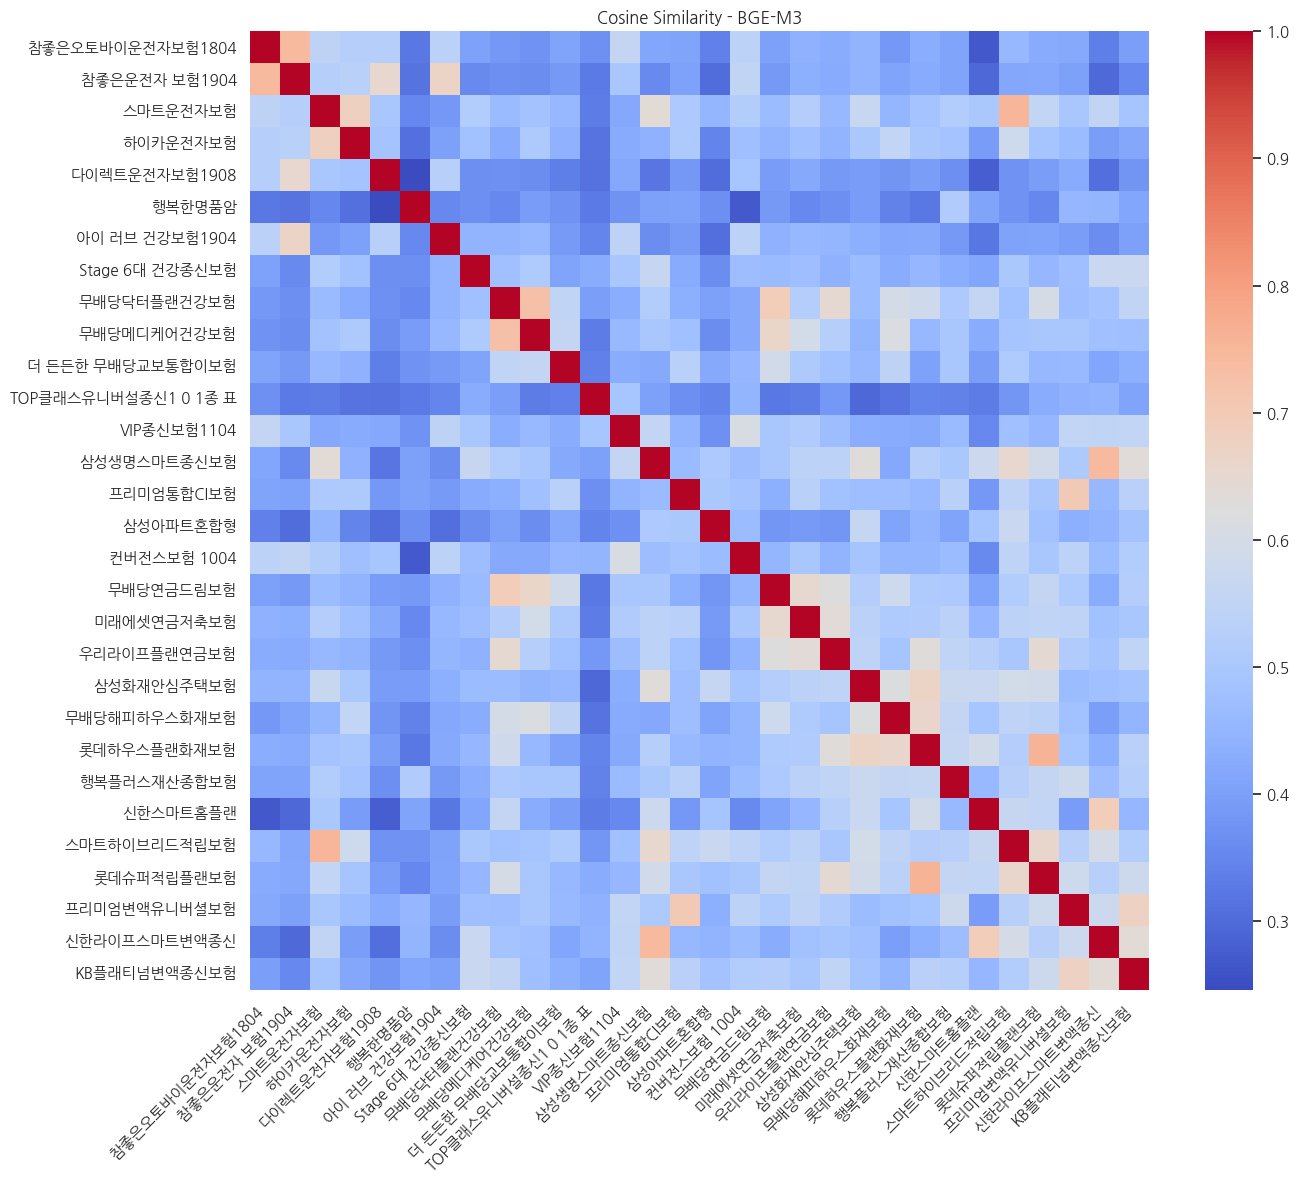


▶ Processing model: KURE-v1


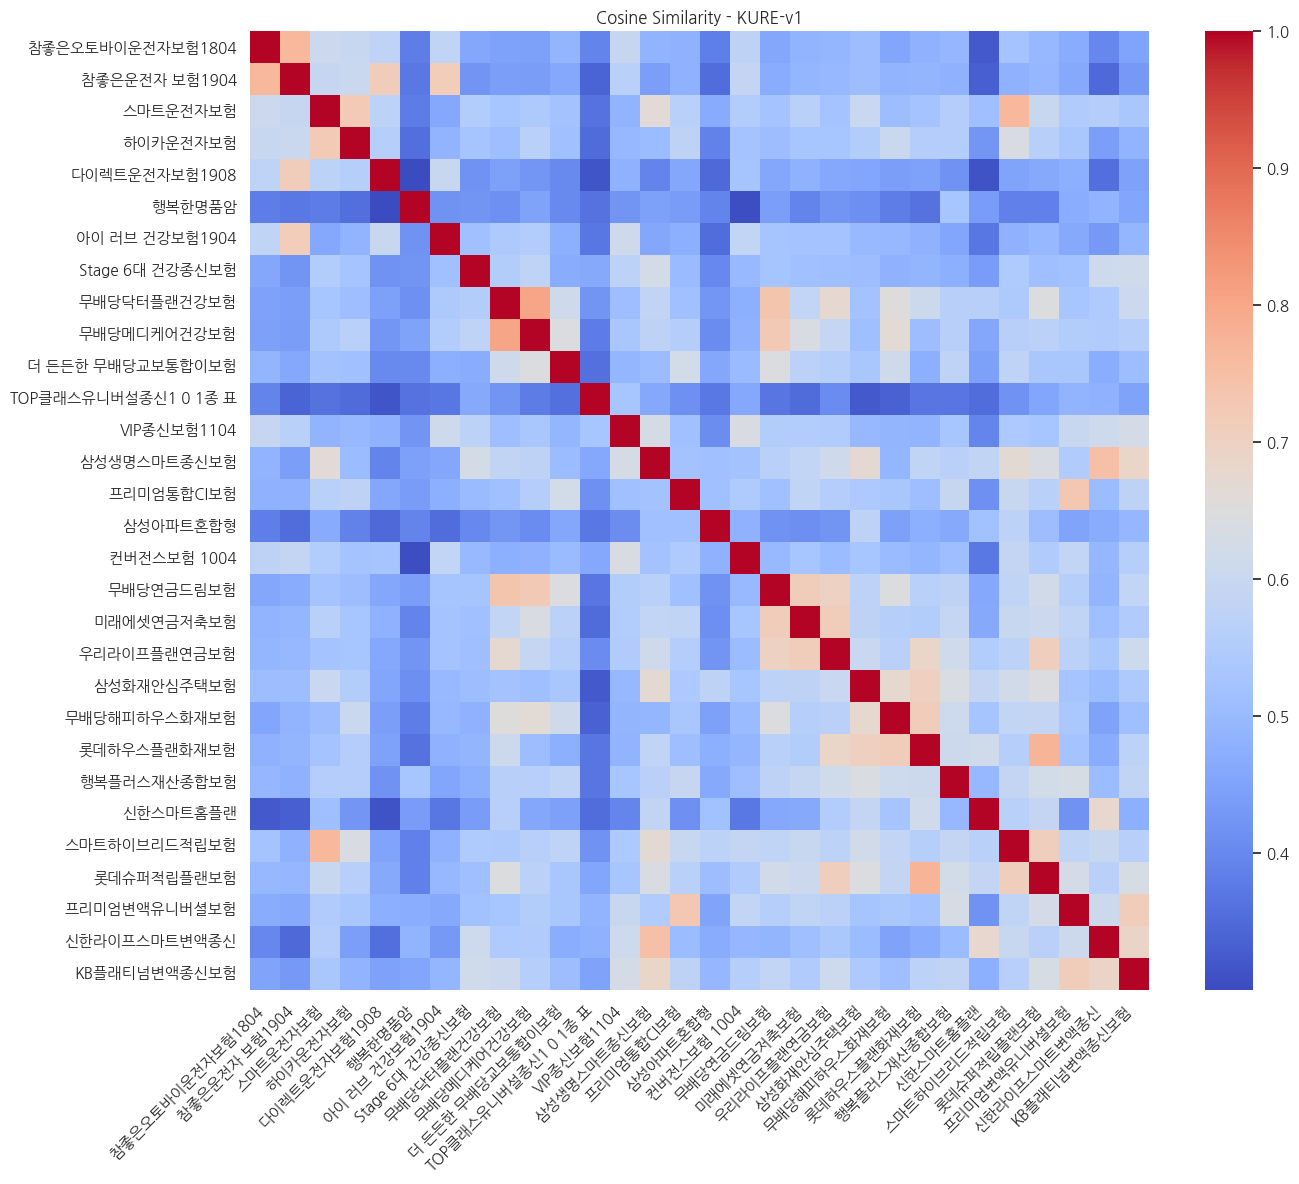


▶ Processing model: Nomic-Embed-V2


configuration_hf_nomic_bert.py:   0%|          | 0.00/1.96k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- configuration_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_hf_nomic_bert.py:   0%|          | 0.00/104k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- modeling_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

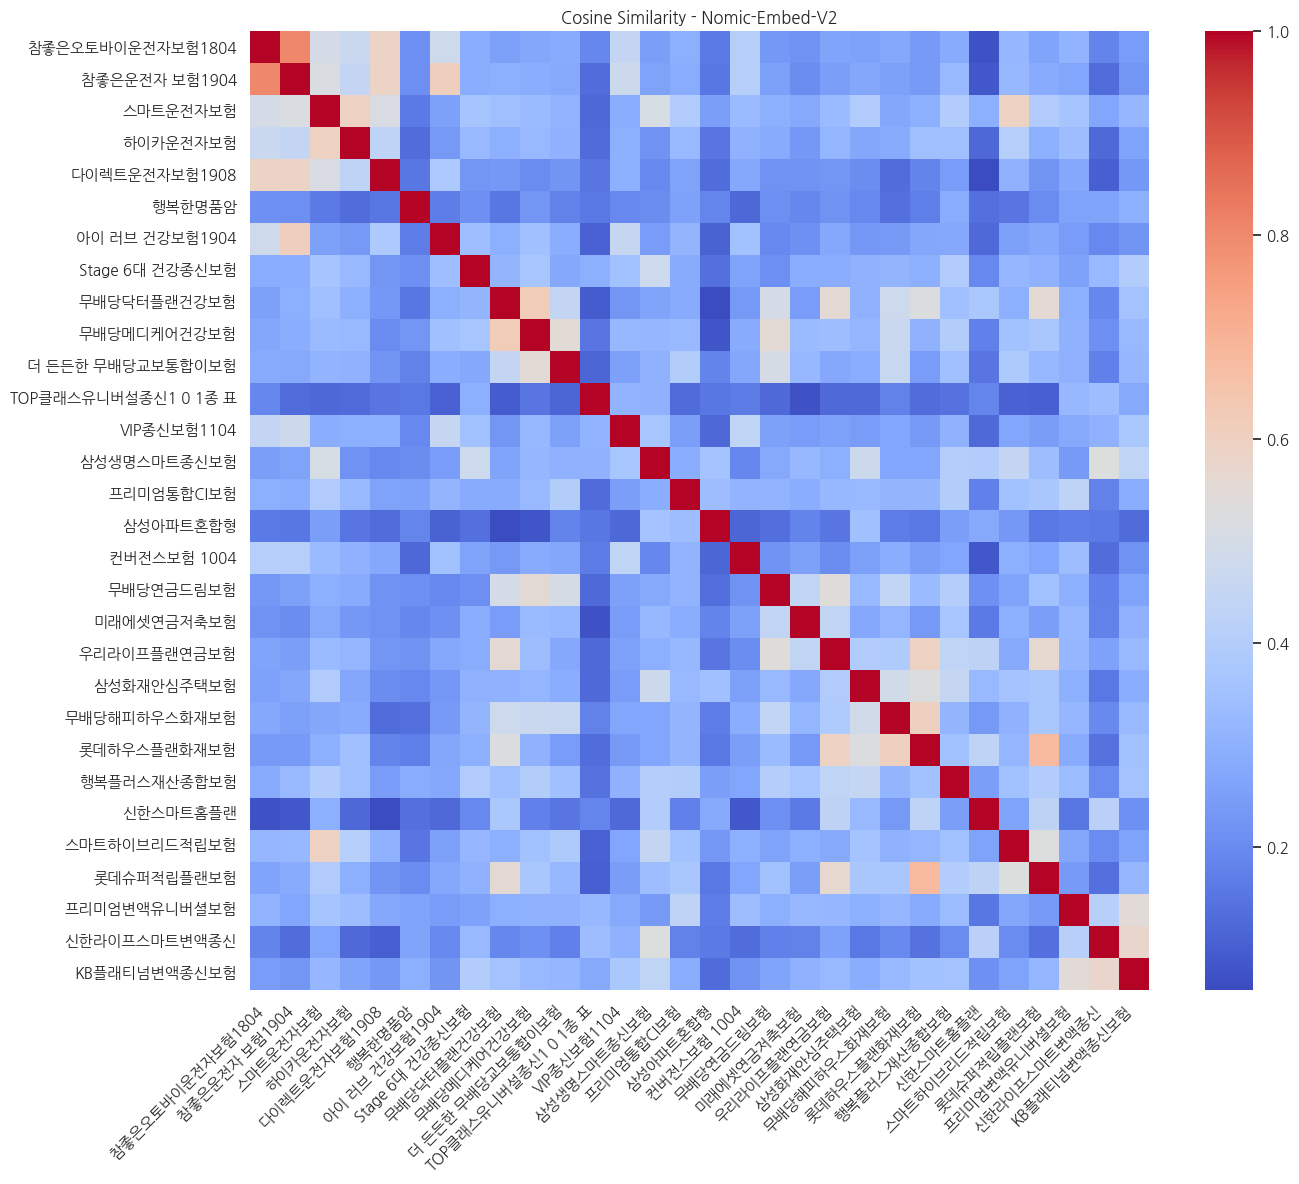


▶ Processing model: Qwen3-Embedding
⚠️ Error loading Qwen3-Embedding: Qwen/Qwen3-embedding is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

▶ Processing model: E5


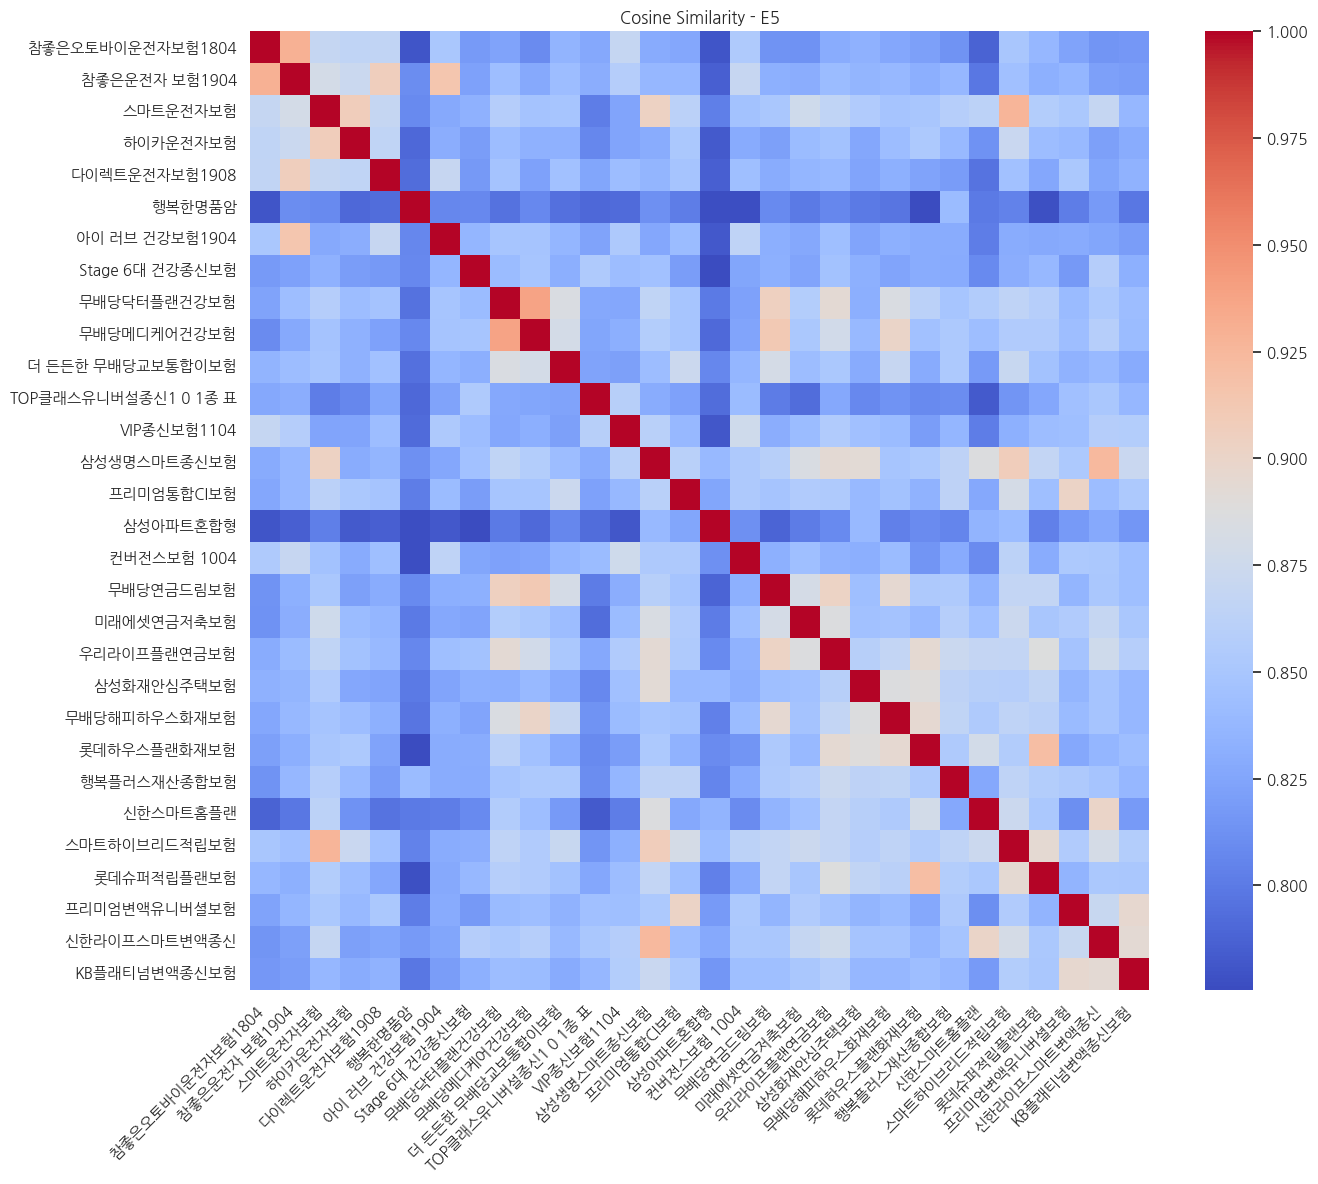


▶ Processing model: KANANA


configuration_kanana2vec.py:   0%|          | 0.00/10.8k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/kakaocorp/kanana-nano-2.1b-embedding:
- configuration_kanana2vec.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_kanana2vec.py:   0%|          | 0.00/9.50k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/kakaocorp/kanana-nano-2.1b-embedding:
- modeling_kanana2vec.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


⚠️ Error loading KANANA: cannot import name 'LLAMA_INPUTS_DOCSTRING' from 'transformers.models.llama.modeling_llama' (/usr/local/lib/python3.11/dist-packages/transformers/models/llama/modeling_llama.py)


In [8]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 보험/금융 상품명 리스트 (30개 샘플)
product_names = [
    '참좋은오토바이운전자보험1804',
    '참좋은운전자 보험1904',
    '스마트운전자보험',
    '하이카운전자보험',
    '다이렉트운전자보험1908',
    '행복한명품암',
    '아이 러브 건강보험1904',
    'Stage 6대 건강종신보험',
    '무배당닥터플랜건강보험',
    '무배당메디케어건강보험',
    '더 든든한 무배당교보통합이보험',
    'TOP클래스유니버설종신1 0 1종 표',
    'VIP종신보험1104',
    '삼성생명스마트종신보험',
    '프리미엄통합CI보험',
    '삼성아파트혼합형',
    '컨버전스보험 1004',
    '무배당연금드림보험',
    '미래에셋연금저축보험',
    '우리라이프플랜연금보험',
    '삼성화재안심주택보험',
    '무배당해피하우스화재보험',
    '롯데하우스플랜화재보험',
    '행복플러스재산종합보험',
    '신한스마트홈플랜',
    '스마트하이브리드적립보험',
    '롯데슈퍼적립플랜보험',
    '프리미엄변액유니버셜보험',
    '신한라이프스마트변액종신',
    'KB플래티넘변액종신보험'
]

# ✅ 사용할 모델 (주신 model_names)
model_names = {
    "BGE-M3": "BAAI/bge-m3",
    "KURE-v1": "nlpai-lab/KURE-v1",
    "Nomic-Embed-V2": "nomic-ai/nomic-embed-text-v2-moe",
    "Qwen3-Embedding": "Qwen/Qwen3-embedding",
    "E5": "intfloat/multilingual-e5-large",
    "KANANA": "kakaocorp/kanana-nano-2.1b-embedding"
}

# ✅ SentenceTransformer 기반 여부 판단
def is_sentence_transformer_model(model_name):
    return any(keyword in model_name.lower() for keyword in [
        "bge", "kure", "nomic", "e5", "kanana"
    ])  # Qwen은 transformers 기반 처리

# ✅ 임베딩 생성 함수
def get_embeddings(model_name, texts):
    if is_sentence_transformer_model(model_name):
        model = SentenceTransformer(model_name, trust_remote_code=True)
        embeddings = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True)
        return embeddings.cpu().numpy()
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        model.eval()
        with torch.no_grad():
            inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings.cpu().numpy()

# ✅ 시각화 함수
def plot_similarity_matrix(similarity_matrix, labels, model_name):
    plt.figure(figsize=(14, 12))  # 넓은 matrix 대응
    sns.heatmap(similarity_matrix, xticklabels=labels, yticklabels=labels,
                cmap='coolwarm', annot=False)  # 30개라 annot=False 추천
    plt.title(f"Cosine Similarity - {model_name}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ✅ 실행
for display_name, model_id in model_names.items():
    try:
        print(f"\n▶ Processing model: {display_name}")
        embeddings = get_embeddings(model_id, product_names)
        similarity_matrix = cosine_similarity(embeddings)
        plot_similarity_matrix(similarity_matrix, product_names, display_name)
    except Exception as e:
        print(f"⚠️ Error loading {display_name}: {e}")



▶ Processing model: BGE-M3


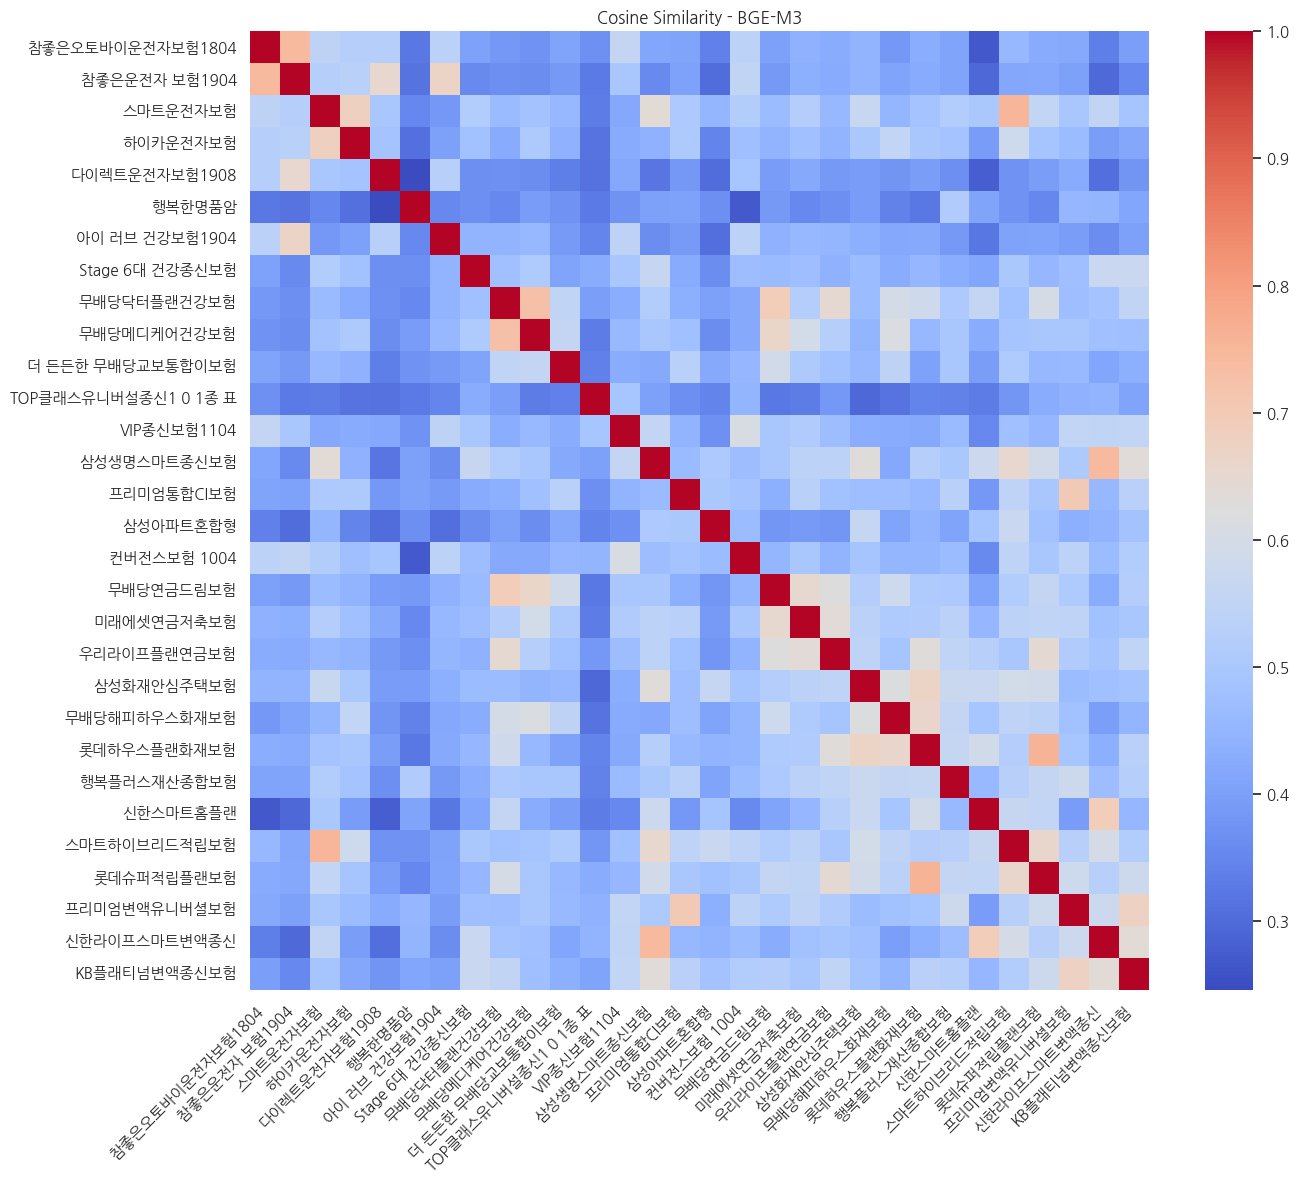


▶ Top-10 유사 상품명 쌍 (BGE-M3):
  - (롯데하우스플랜화재보험) <-> (롯데슈퍼적립플랜보험) | Cosine Similarity: 0.7597
  - (스마트운전자보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.7549
  - (삼성생명스마트종신보험) <-> (신한라이프스마트변액종신) | Cosine Similarity: 0.7435
  - (참좋은오토바이운전자보험1804) <-> (참좋은운전자 보험1904) | Cosine Similarity: 0.7414
  - (무배당닥터플랜건강보험) <-> (무배당메디케어건강보험) | Cosine Similarity: 0.7269
  - (프리미엄통합CI보험) <-> (프리미엄변액유니버셜보험) | Cosine Similarity: 0.7038
  - (무배당닥터플랜건강보험) <-> (무배당연금드림보험) | Cosine Similarity: 0.6934
  - (신한스마트홈플랜) <-> (신한라이프스마트변액종신) | Cosine Similarity: 0.6910
  - (스마트운전자보험) <-> (하이카운전자보험) | Cosine Similarity: 0.6803
  - (프리미엄변액유니버셜보험) <-> (KB플래티넘변액종신보험) | Cosine Similarity: 0.6738

▶ Processing model: KURE-v1


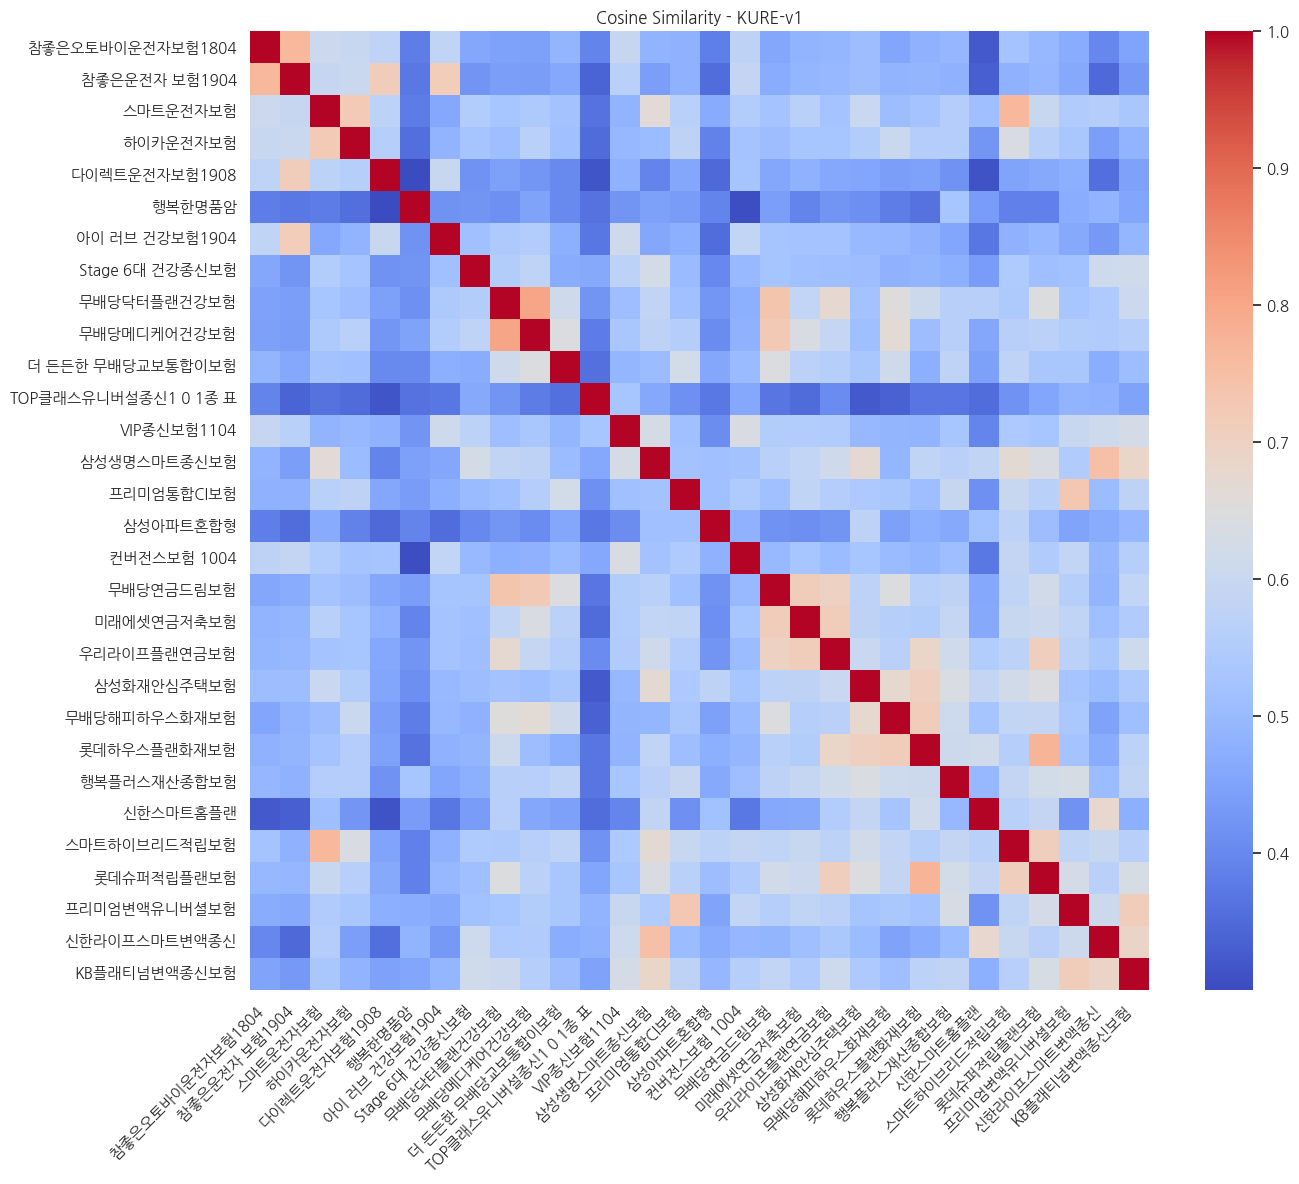


▶ Top-10 유사 상품명 쌍 (KURE-v1):
  - (무배당닥터플랜건강보험) <-> (무배당메디케어건강보험) | Cosine Similarity: 0.8055
  - (롯데하우스플랜화재보험) <-> (롯데슈퍼적립플랜보험) | Cosine Similarity: 0.7739
  - (참좋은오토바이운전자보험1804) <-> (참좋은운전자 보험1904) | Cosine Similarity: 0.7675
  - (스마트운전자보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.7670
  - (삼성생명스마트종신보험) <-> (신한라이프스마트변액종신) | Cosine Similarity: 0.7468
  - (무배당닥터플랜건강보험) <-> (무배당연금드림보험) | Cosine Similarity: 0.7363
  - (프리미엄통합CI보험) <-> (프리미엄변액유니버셜보험) | Cosine Similarity: 0.7304
  - (무배당메디케어건강보험) <-> (무배당연금드림보험) | Cosine Similarity: 0.7262
  - (스마트운전자보험) <-> (하이카운전자보험) | Cosine Similarity: 0.7219
  - (참좋은운전자 보험1904) <-> (아이 러브 건강보험1904) | Cosine Similarity: 0.7156

▶ Processing model: Nomic-Embed-V2


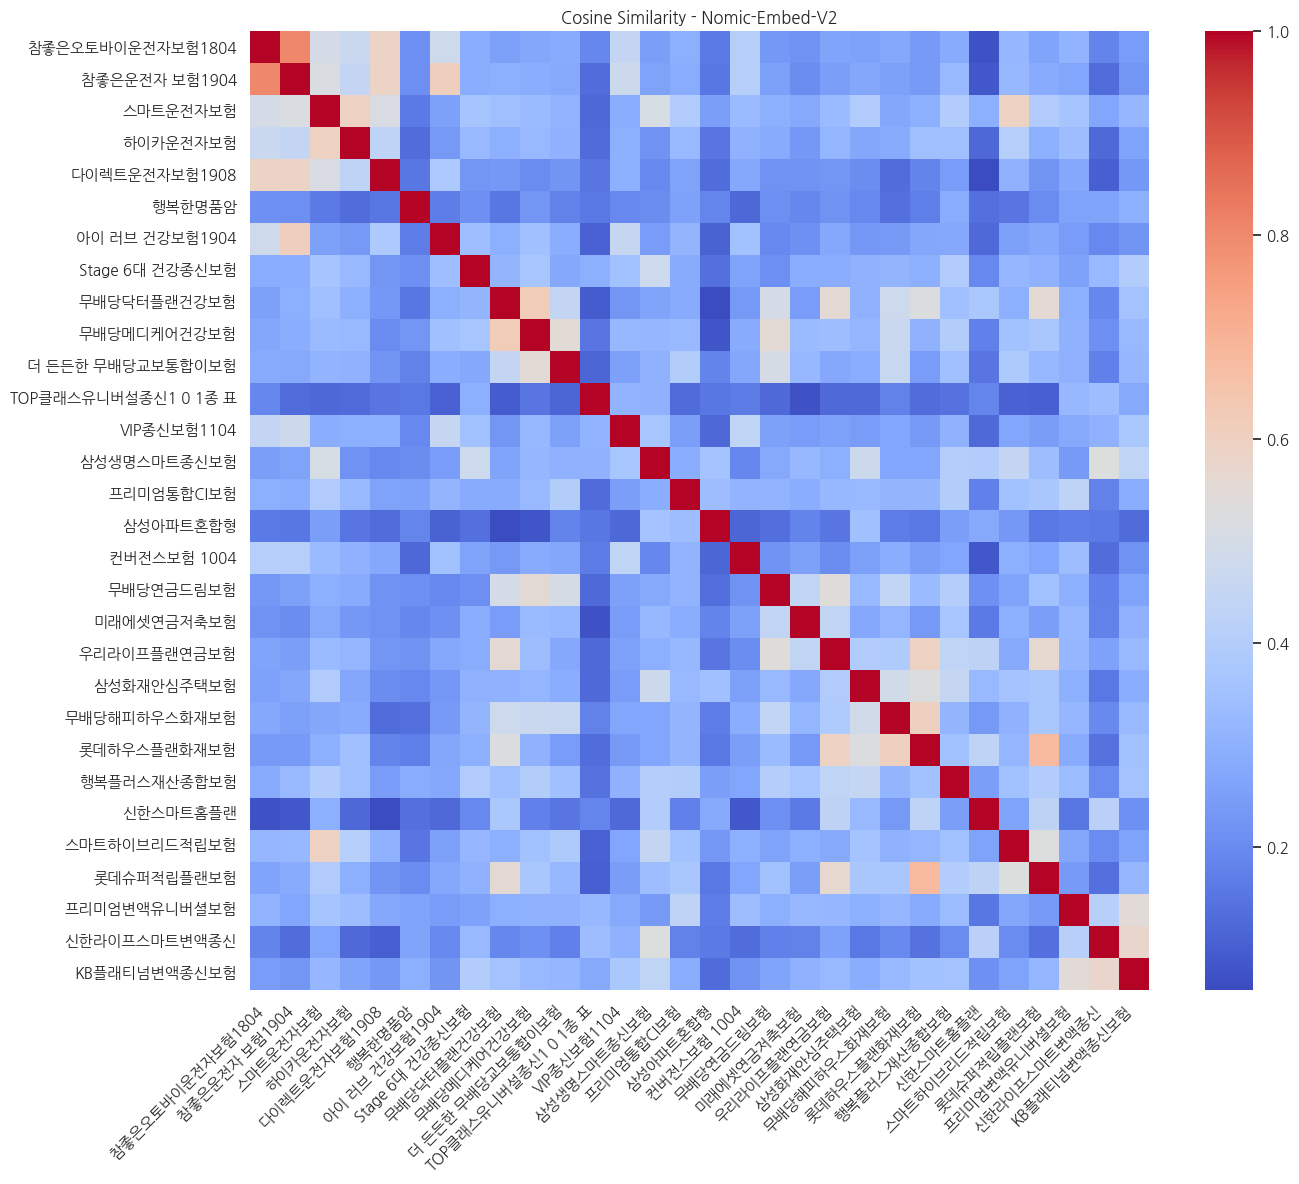


▶ Top-10 유사 상품명 쌍 (Nomic-Embed-V2):
  - (참좋은오토바이운전자보험1804) <-> (참좋은운전자 보험1904) | Cosine Similarity: 0.8027
  - (롯데하우스플랜화재보험) <-> (롯데슈퍼적립플랜보험) | Cosine Similarity: 0.6792
  - (무배당닥터플랜건강보험) <-> (무배당메디케어건강보험) | Cosine Similarity: 0.6200
  - (참좋은운전자 보험1904) <-> (아이 러브 건강보험1904) | Cosine Similarity: 0.6092
  - (무배당해피하우스화재보험) <-> (롯데하우스플랜화재보험) | Cosine Similarity: 0.6027
  - (스마트운전자보험) <-> (하이카운전자보험) | Cosine Similarity: 0.5981
  - (스마트운전자보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.5971
  - (우리라이프플랜연금보험) <-> (롯데하우스플랜화재보험) | Cosine Similarity: 0.5928
  - (참좋은운전자 보험1904) <-> (다이렉트운전자보험1908) | Cosine Similarity: 0.5879
  - (참좋은오토바이운전자보험1804) <-> (다이렉트운전자보험1908) | Cosine Similarity: 0.5852

▶ Processing model: Qwen3-Embedding
⚠️ Error loading Qwen3-Embedding: Qwen/Qwen3-embedding is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with 

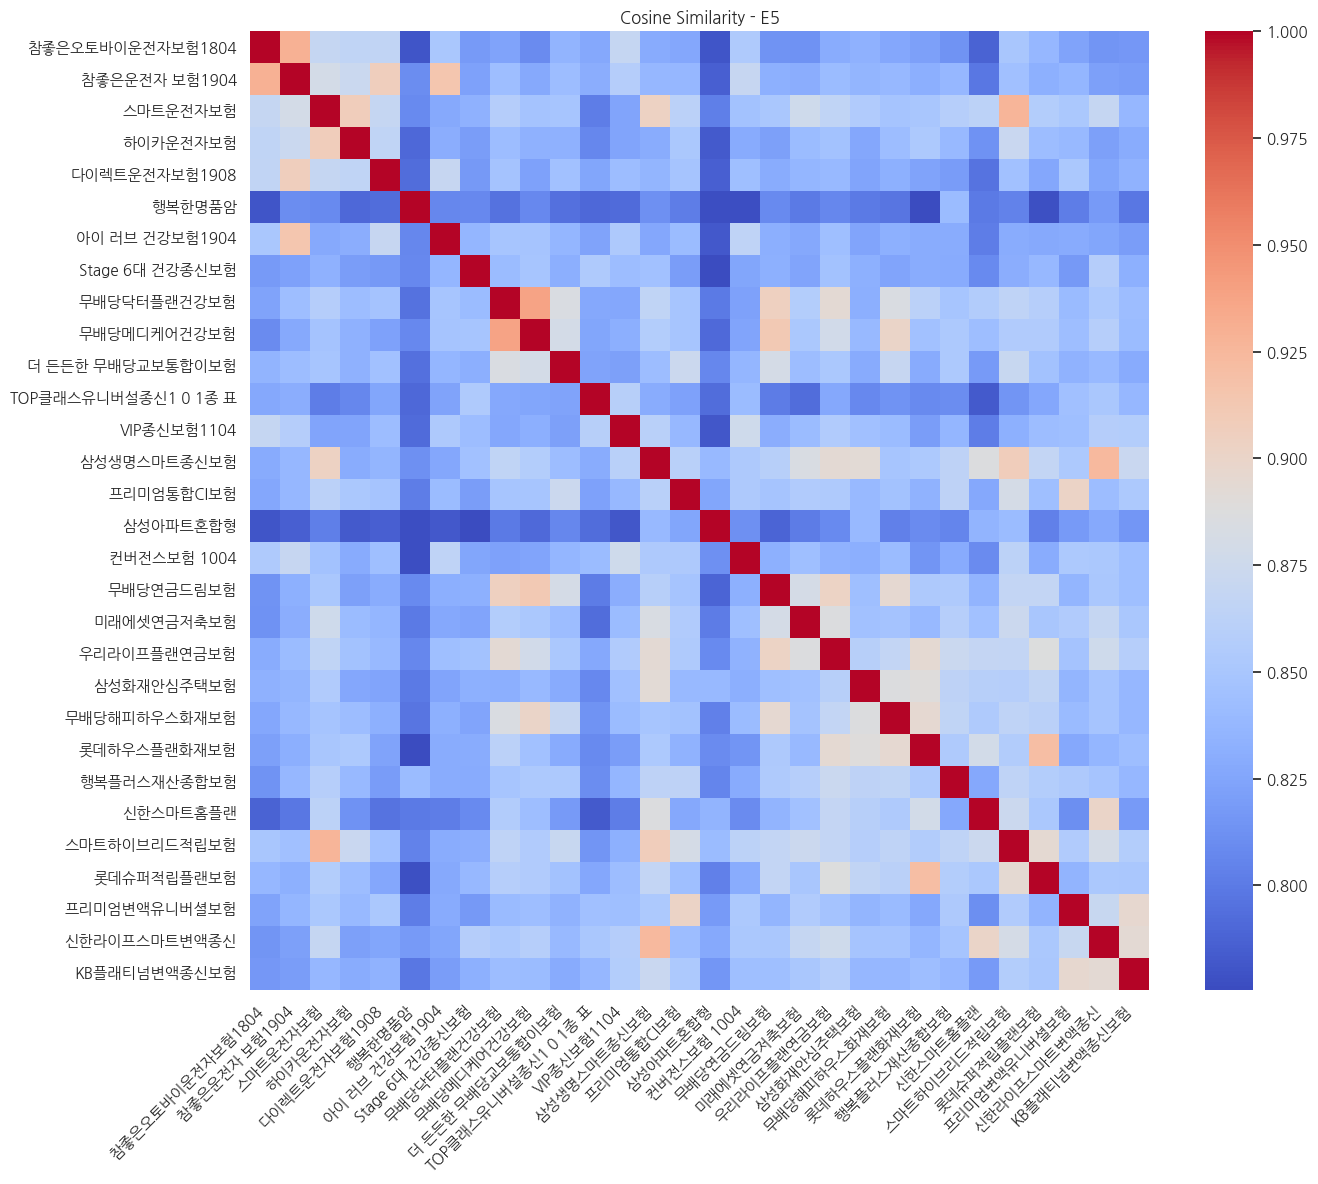


▶ Top-10 유사 상품명 쌍 (E5):
  - (무배당닥터플랜건강보험) <-> (무배당메디케어건강보험) | Cosine Similarity: 0.9379
  - (참좋은오토바이운전자보험1804) <-> (참좋은운전자 보험1904) | Cosine Similarity: 0.9298
  - (스마트운전자보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.9267
  - (삼성생명스마트종신보험) <-> (신한라이프스마트변액종신) | Cosine Similarity: 0.9240
  - (롯데하우스플랜화재보험) <-> (롯데슈퍼적립플랜보험) | Cosine Similarity: 0.9205
  - (참좋은운전자 보험1904) <-> (아이 러브 건강보험1904) | Cosine Similarity: 0.9146
  - (무배당메디케어건강보험) <-> (무배당연금드림보험) | Cosine Similarity: 0.9123
  - (삼성생명스마트종신보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.9077
  - (스마트운전자보험) <-> (하이카운전자보험) | Cosine Similarity: 0.9076
  - (참좋은운전자 보험1904) <-> (다이렉트운전자보험1908) | Cosine Similarity: 0.9066

▶ Processing model: KANANA
⚠️ Error loading KANANA: cannot import name 'LLAMA_INPUTS_DOCSTRING' from 'transformers.models.llama.modeling_llama' (/usr/local/lib/python3.11/dist-packages/transformers/models/llama/modeling_llama.py)


In [9]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from itertools import combinations

# ✅ 보험/금융 상품명 리스트 (30개 샘플)
product_names = [
    '참좋은오토바이운전자보험1804',
    '참좋은운전자 보험1904',
    '스마트운전자보험',
    '하이카운전자보험',
    '다이렉트운전자보험1908',
    '행복한명품암',
    '아이 러브 건강보험1904',
    'Stage 6대 건강종신보험',
    '무배당닥터플랜건강보험',
    '무배당메디케어건강보험',
    '더 든든한 무배당교보통합이보험',
    'TOP클래스유니버설종신1 0 1종 표',
    'VIP종신보험1104',
    '삼성생명스마트종신보험',
    '프리미엄통합CI보험',
    '삼성아파트혼합형',
    '컨버전스보험 1004',
    '무배당연금드림보험',
    '미래에셋연금저축보험',
    '우리라이프플랜연금보험',
    '삼성화재안심주택보험',
    '무배당해피하우스화재보험',
    '롯데하우스플랜화재보험',
    '행복플러스재산종합보험',
    '신한스마트홈플랜',
    '스마트하이브리드적립보험',
    '롯데슈퍼적립플랜보험',
    '프리미엄변액유니버셜보험',
    '신한라이프스마트변액종신',
    'KB플래티넘변액종신보험'
]

# ✅ 사용할 모델 (주신 model_names)
model_names = {
    "BGE-M3": "BAAI/bge-m3",
    "KURE-v1": "nlpai-lab/KURE-v1",
    "Nomic-Embed-V2": "nomic-ai/nomic-embed-text-v2-moe",
    "Qwen3-Embedding": "Qwen/Qwen3-embedding",
    "E5": "intfloat/multilingual-e5-large",
    "KANANA": "kakaocorp/kanana-nano-2.1b-embedding"
}

# ✅ SentenceTransformer 기반 여부 판단
def is_sentence_transformer_model(model_name):
    return any(keyword in model_name.lower() for keyword in [
        "bge", "kure", "nomic", "e5", "kanana"
    ])  # Qwen은 transformers 기반 처리

# ✅ 임베딩 생성 함수
def get_embeddings(model_name, texts):
    if is_sentence_transformer_model(model_name):
        model = SentenceTransformer(model_name, trust_remote_code=True)
        embeddings = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True)
        return embeddings.cpu().numpy()
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        model.eval()
        with torch.no_grad():
            inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings.cpu().numpy()

# ✅ 시각화 함수
def plot_similarity_matrix(similarity_matrix, labels, model_name):
    plt.figure(figsize=(14, 12))
    sns.heatmap(similarity_matrix, xticklabels=labels, yticklabels=labels,
                cmap='coolwarm', annot=False)
    plt.title(f"Cosine Similarity - {model_name}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ✅ Top-N 유사 쌍 추출 함수
def get_top_n_similar_pairs(similarity_matrix, labels, top_n=10):
    pairs = []
    num_items = len(labels)
    for i, j in combinations(range(num_items), 2):
        pairs.append((labels[i], labels[j], similarity_matrix[i, j]))
    # Sort by similarity descending
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    return pairs[:top_n]

# ✅ 실행
for display_name, model_id in model_names.items():
    try:
        print(f"\n▶ Processing model: {display_name}")
        embeddings = get_embeddings(model_id, product_names)
        similarity_matrix = cosine_similarity(embeddings)

        # 1️⃣ 히트맵 출력
        plot_similarity_matrix(similarity_matrix, product_names, display_name)

        # 2️⃣ Top-N 유사쌍 출력
        top_pairs = get_top_n_similar_pairs(similarity_matrix, product_names, top_n=10)
        print(f"\n▶ Top-10 유사 상품명 쌍 ({display_name}):")
        for p1, p2, score in top_pairs:
            print(f"  - ({p1}) <-> ({p2}) | Cosine Similarity: {score:.4f}")

    except Exception as e:
        print(f"⚠️ Error loading {display_name}: {e}")



▶ Processing model: BGE-M3


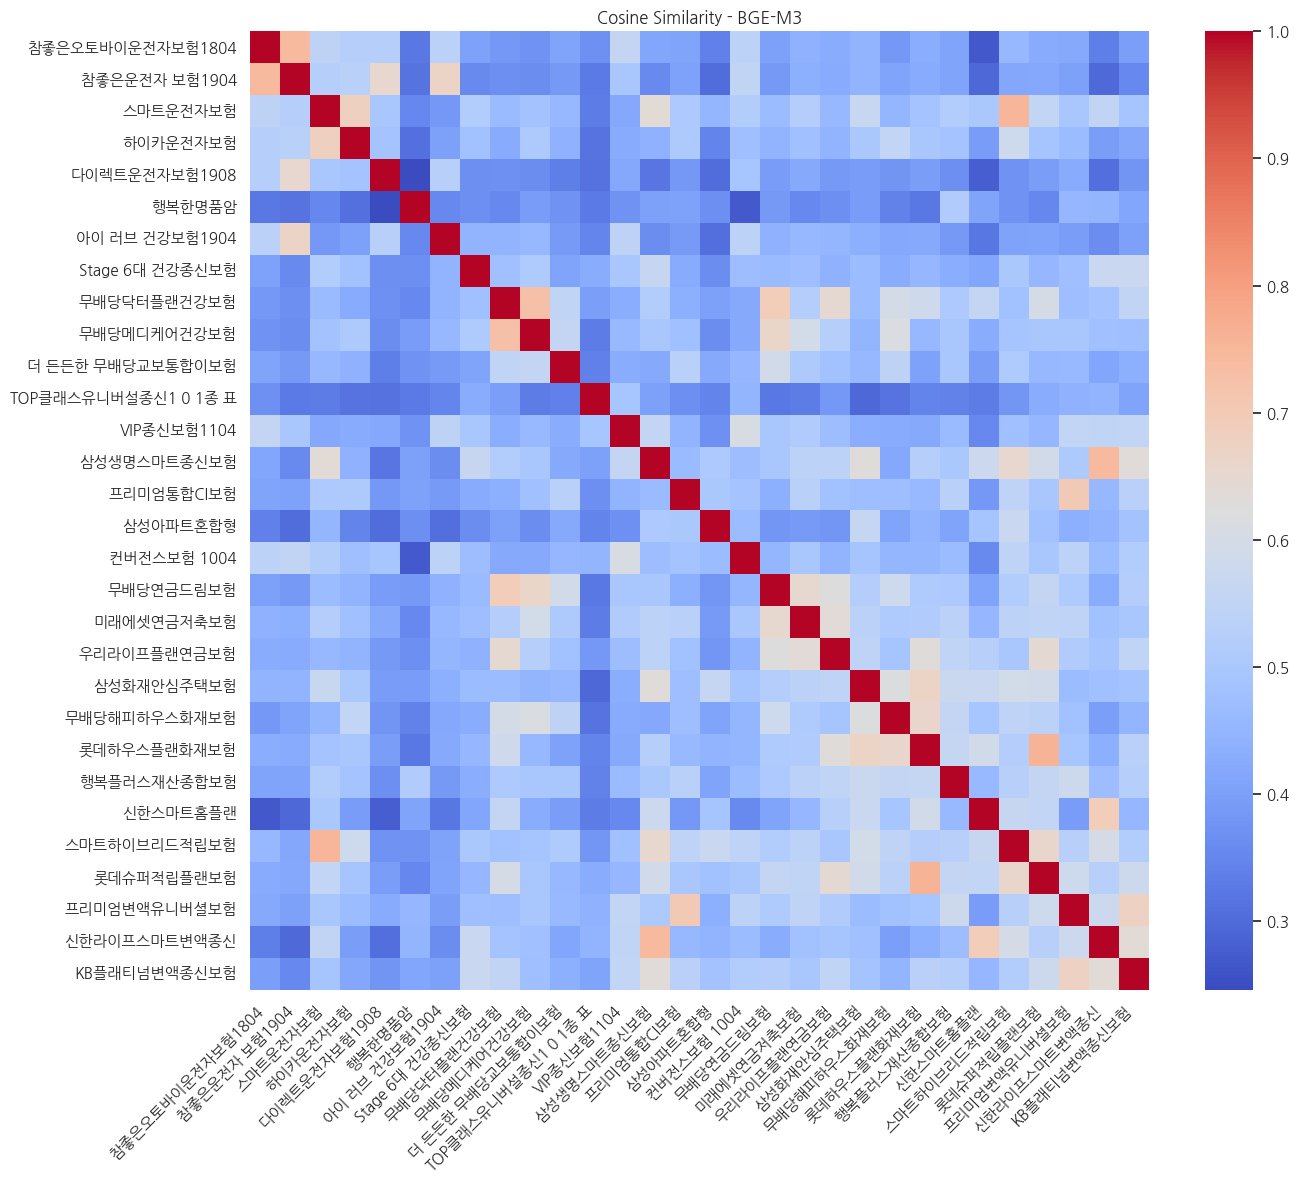


▶ 유사도 0.85 이상인 상품명 쌍 (BGE-M3):
  - 없음

▶ Processing model: KURE-v1


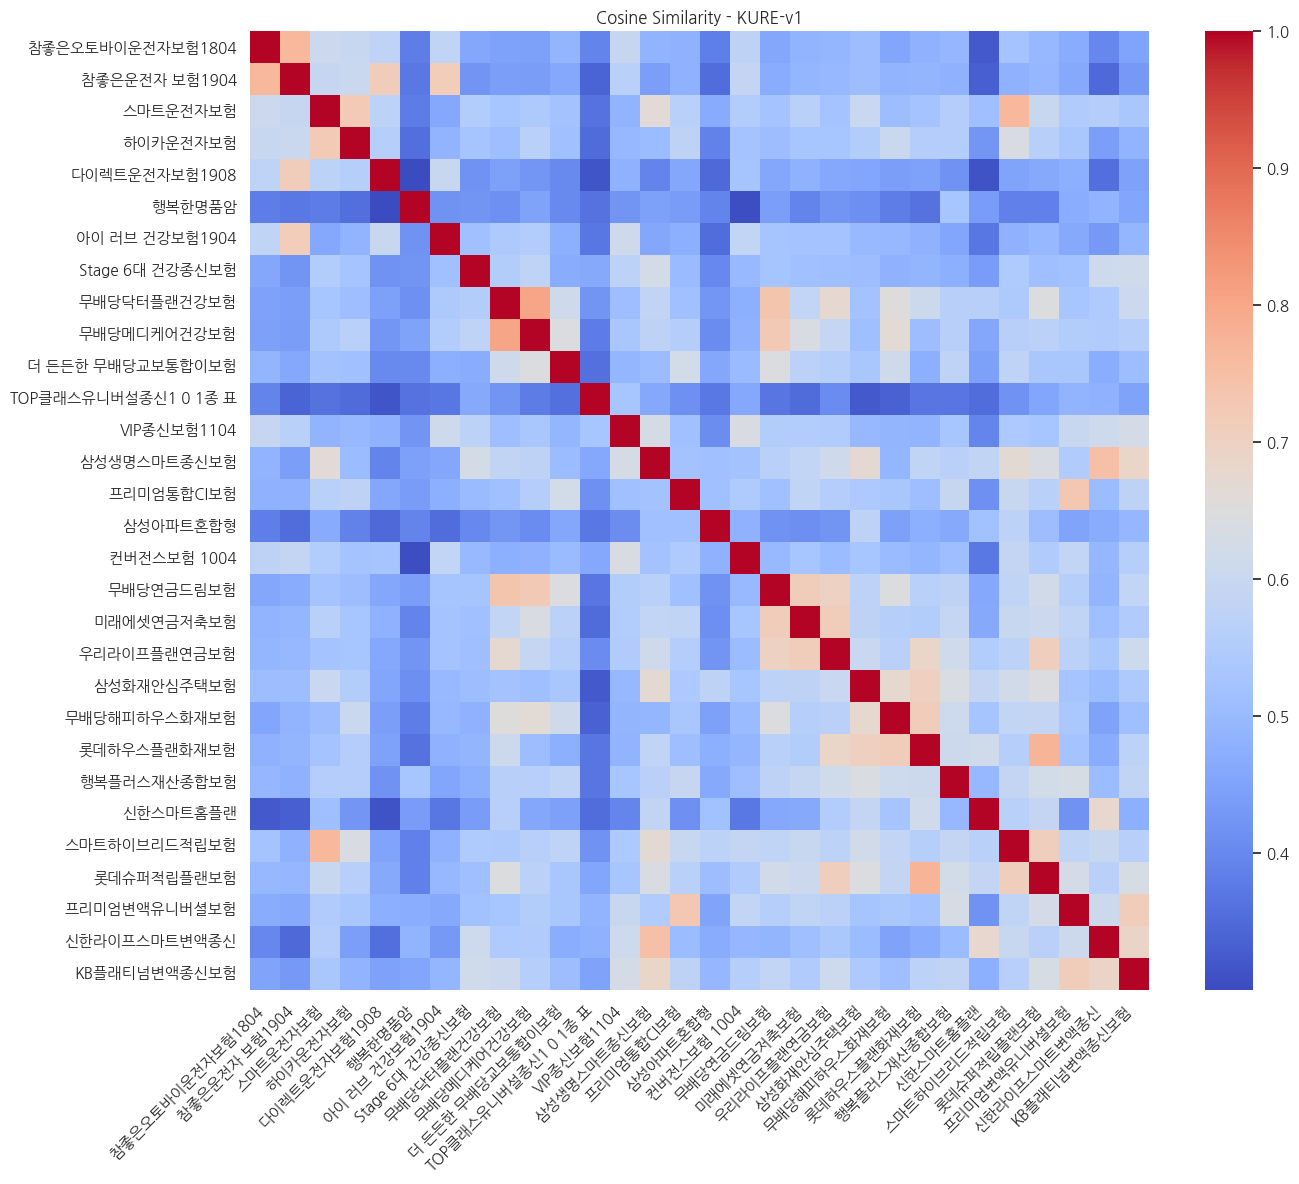


▶ 유사도 0.85 이상인 상품명 쌍 (KURE-v1):
  - 없음

▶ Processing model: Nomic-Embed-V2


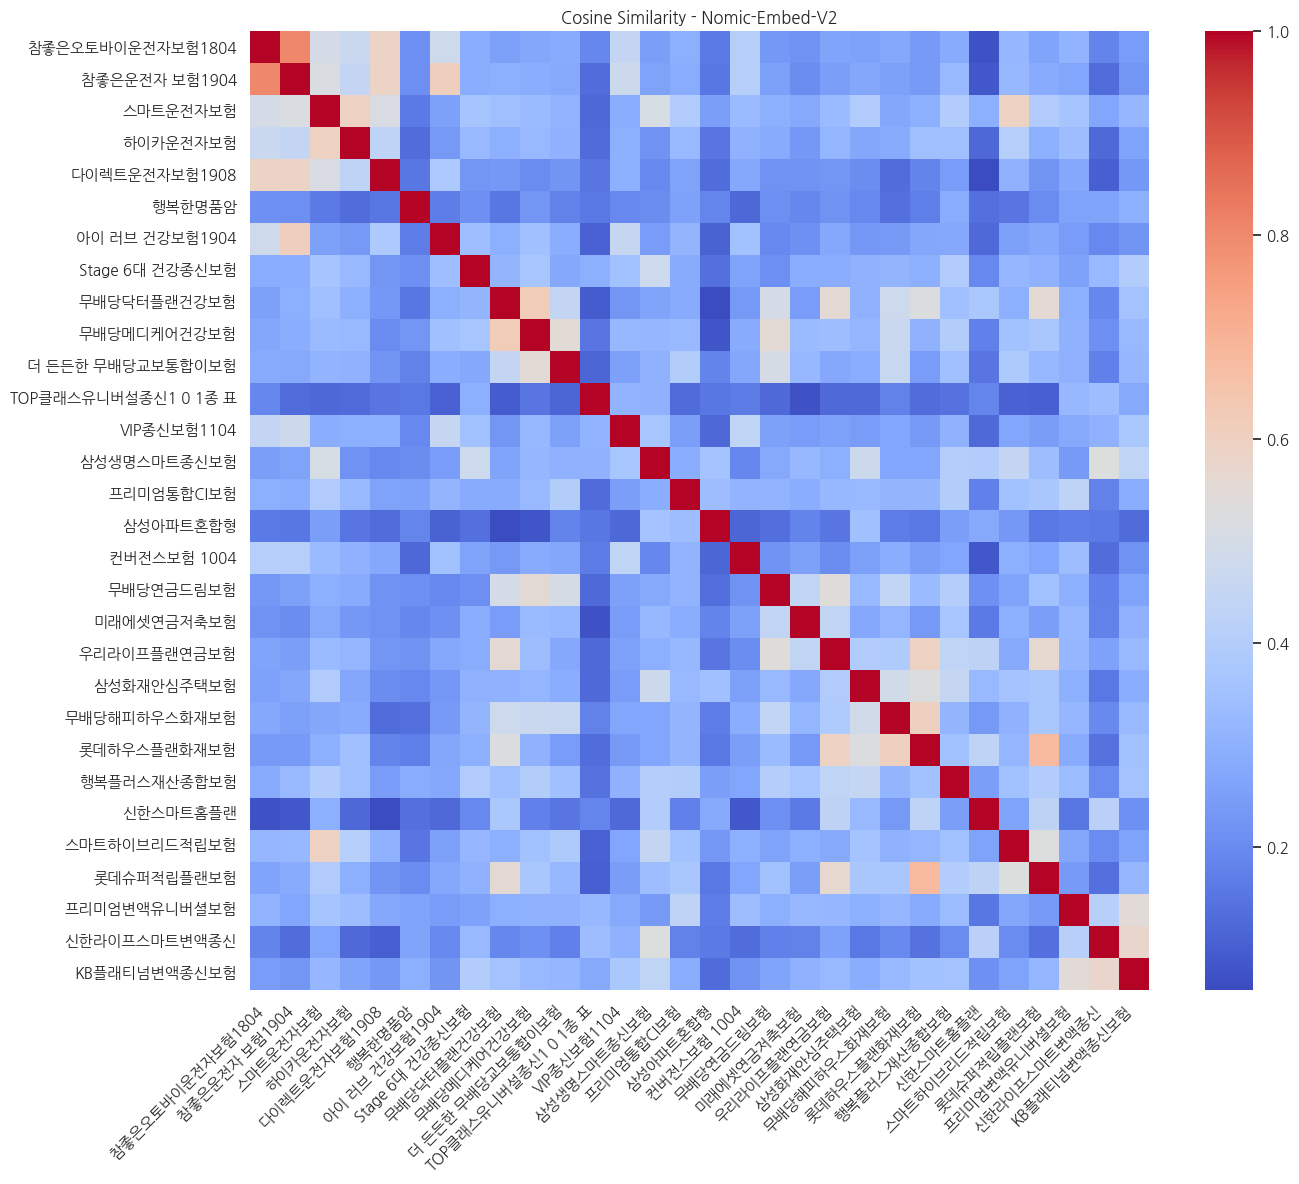


▶ 유사도 0.85 이상인 상품명 쌍 (Nomic-Embed-V2):
  - 없음

▶ Processing model: Qwen3-Embedding
⚠️ Error loading Qwen3-Embedding: Qwen/Qwen3-embedding is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

▶ Processing model: E5


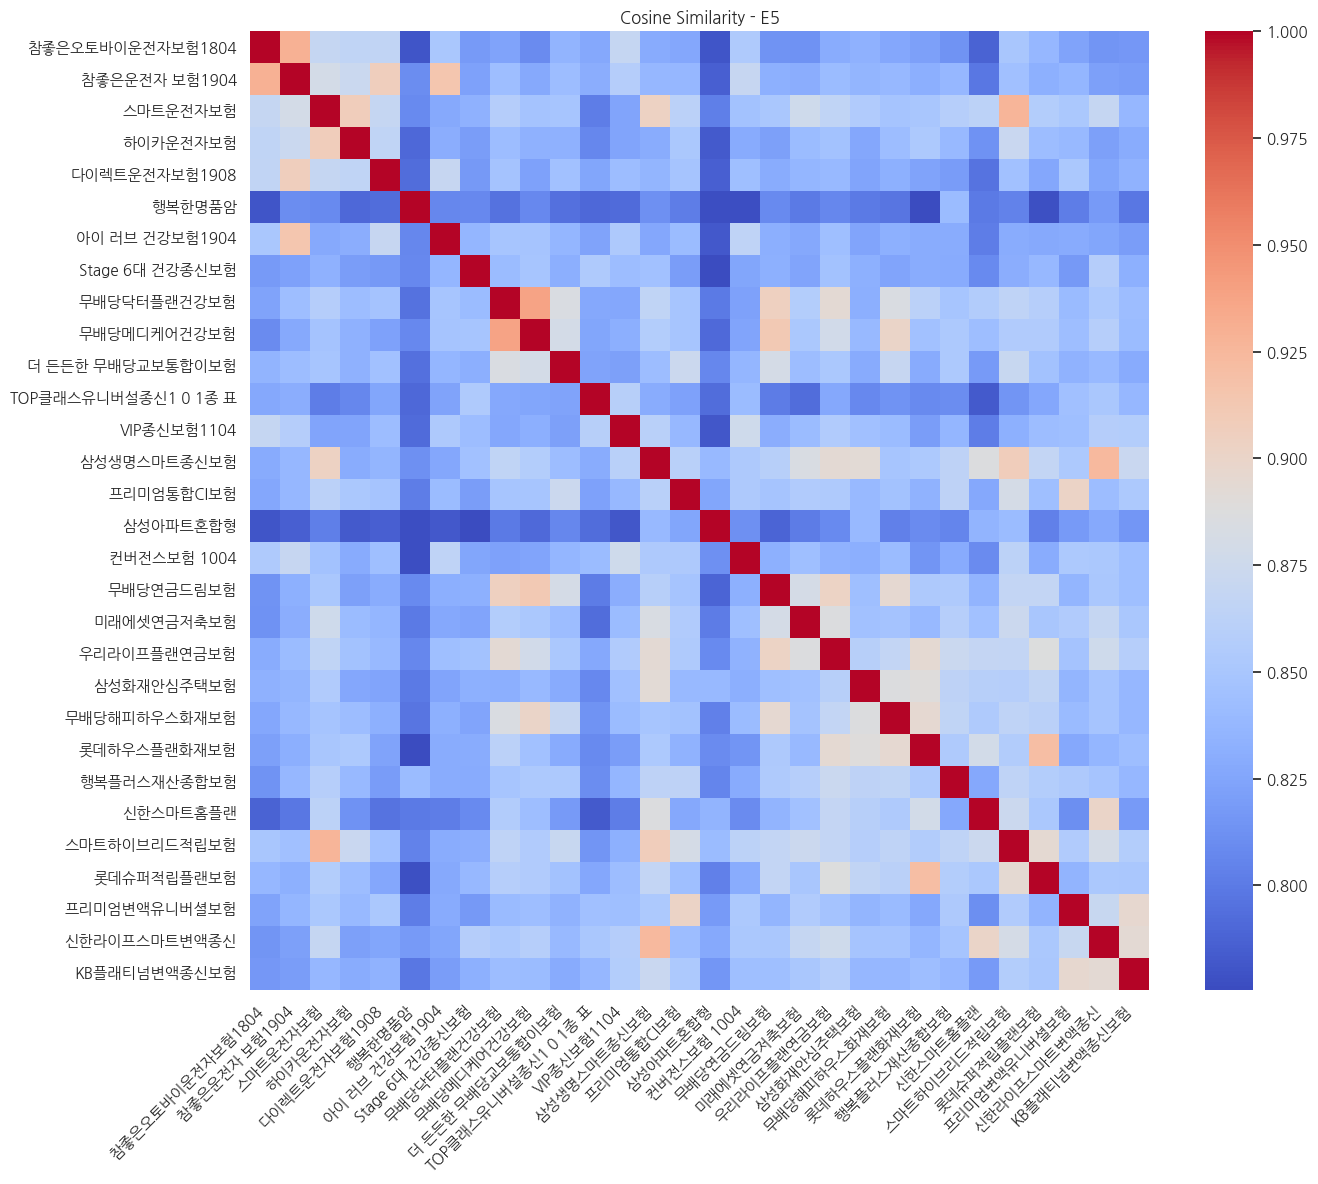


▶ 유사도 0.85 이상인 상품명 쌍 (E5):
  - (무배당닥터플랜건강보험) <-> (무배당메디케어건강보험) | Cosine Similarity: 0.9379
  - (참좋은오토바이운전자보험1804) <-> (참좋은운전자 보험1904) | Cosine Similarity: 0.9298
  - (스마트운전자보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.9267
  - (삼성생명스마트종신보험) <-> (신한라이프스마트변액종신) | Cosine Similarity: 0.9240
  - (롯데하우스플랜화재보험) <-> (롯데슈퍼적립플랜보험) | Cosine Similarity: 0.9205
  - (참좋은운전자 보험1904) <-> (아이 러브 건강보험1904) | Cosine Similarity: 0.9146
  - (무배당메디케어건강보험) <-> (무배당연금드림보험) | Cosine Similarity: 0.9123
  - (삼성생명스마트종신보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.9077
  - (스마트운전자보험) <-> (하이카운전자보험) | Cosine Similarity: 0.9076
  - (참좋은운전자 보험1904) <-> (다이렉트운전자보험1908) | Cosine Similarity: 0.9066
  - (무배당닥터플랜건강보험) <-> (무배당연금드림보험) | Cosine Similarity: 0.9048
  - (스마트운전자보험) <-> (삼성생명스마트종신보험) | Cosine Similarity: 0.9033
  - (무배당연금드림보험) <-> (우리라이프플랜연금보험) | Cosine Similarity: 0.9025
  - (프리미엄통합CI보험) <-> (프리미엄변액유니버셜보험) | Cosine Similarity: 0.9014
  - (무배당메디케어건강보험) <-> (무배당해피하우스화재보험) | Cosine Similarity: 0.9003
  - (신한스마트홈

In [10]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# ✅ 보험/금융 상품명 리스트 (30개 샘플)
product_names = [
    '참좋은오토바이운전자보험1804',
    '참좋은운전자 보험1904',
    '스마트운전자보험',
    '하이카운전자보험',
    '다이렉트운전자보험1908',
    '행복한명품암',
    '아이 러브 건강보험1904',
    'Stage 6대 건강종신보험',
    '무배당닥터플랜건강보험',
    '무배당메디케어건강보험',
    '더 든든한 무배당교보통합이보험',
    'TOP클래스유니버설종신1 0 1종 표',
    'VIP종신보험1104',
    '삼성생명스마트종신보험',
    '프리미엄통합CI보험',
    '삼성아파트혼합형',
    '컨버전스보험 1004',
    '무배당연금드림보험',
    '미래에셋연금저축보험',
    '우리라이프플랜연금보험',
    '삼성화재안심주택보험',
    '무배당해피하우스화재보험',
    '롯데하우스플랜화재보험',
    '행복플러스재산종합보험',
    '신한스마트홈플랜',
    '스마트하이브리드적립보험',
    '롯데슈퍼적립플랜보험',
    '프리미엄변액유니버셜보험',
    '신한라이프스마트변액종신',
    'KB플래티넘변액종신보험'
]

# ✅ 사용할 모델 (주신 model_names)
model_names = {
    "BGE-M3": "BAAI/bge-m3",
    "KURE-v1": "nlpai-lab/KURE-v1",
    "Nomic-Embed-V2": "nomic-ai/nomic-embed-text-v2-moe",
    "Qwen3-Embedding": "Qwen/Qwen3-embedding",
    "E5": "intfloat/multilingual-e5-large",
    "KANANA": "kakaocorp/kanana-nano-2.1b-embedding"
}

# ✅ SentenceTransformer 기반 여부 판단
def is_sentence_transformer_model(model_name):
    return any(keyword in model_name.lower() for keyword in [
        "bge", "kure", "nomic", "e5", "kanana"
    ])  # Qwen은 transformers 기반 처리

# ✅ 임베딩 생성 함수
def get_embeddings(model_name, texts):
    if is_sentence_transformer_model(model_name):
        model = SentenceTransformer(model_name, trust_remote_code=True)
        embeddings = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True)
        return embeddings.cpu().numpy()
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        model.eval()
        with torch.no_grad():
            inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings.cpu().numpy()

# ✅ 시각화 함수
def plot_similarity_matrix(similarity_matrix, labels, model_name):
    plt.figure(figsize=(14, 12))
    sns.heatmap(similarity_matrix, xticklabels=labels, yticklabels=labels,
                cmap='coolwarm', annot=False)
    plt.title(f"Cosine Similarity - {model_name}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ✅ 유사도 threshold 이상인 쌍만 출력
def get_similar_pairs_above_threshold(similarity_matrix, labels, threshold=0.85):
    pairs = []
    num_items = len(labels)
    for i, j in combinations(range(num_items), 2):
        sim_score = similarity_matrix[i, j]
        if sim_score >= threshold:
            pairs.append((labels[i], labels[j], sim_score))
    # Sort by similarity descending
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    return pairs

# ✅ 실행
# Threshold 설정 (ex: 0.85)
similarity_threshold = 0.85

for display_name, model_id in model_names.items():
    try:
        print(f"\n▶ Processing model: {display_name}")
        embeddings = get_embeddings(model_id, product_names)
        similarity_matrix = cosine_similarity(embeddings)

        # 1️⃣ 히트맵 출력
        plot_similarity_matrix(similarity_matrix, product_names, display_name)

        # 2️⃣ Threshold 이상 유사쌍 출력
        threshold_pairs = get_similar_pairs_above_threshold(similarity_matrix, product_names, threshold=similarity_threshold)
        print(f"\n▶ 유사도 {similarity_threshold} 이상인 상품명 쌍 ({display_name}):")
        if len(threshold_pairs) == 0:
            print("  - 없음")
        else:
            for p1, p2, score in threshold_pairs:
                print(f"  - ({p1}) <-> ({p2}) | Cosine Similarity: {score:.4f}")

    except Exception as e:
        print(f"⚠️ Error loading {display_name}: {e}")



▶ Processing model: BGE-M3


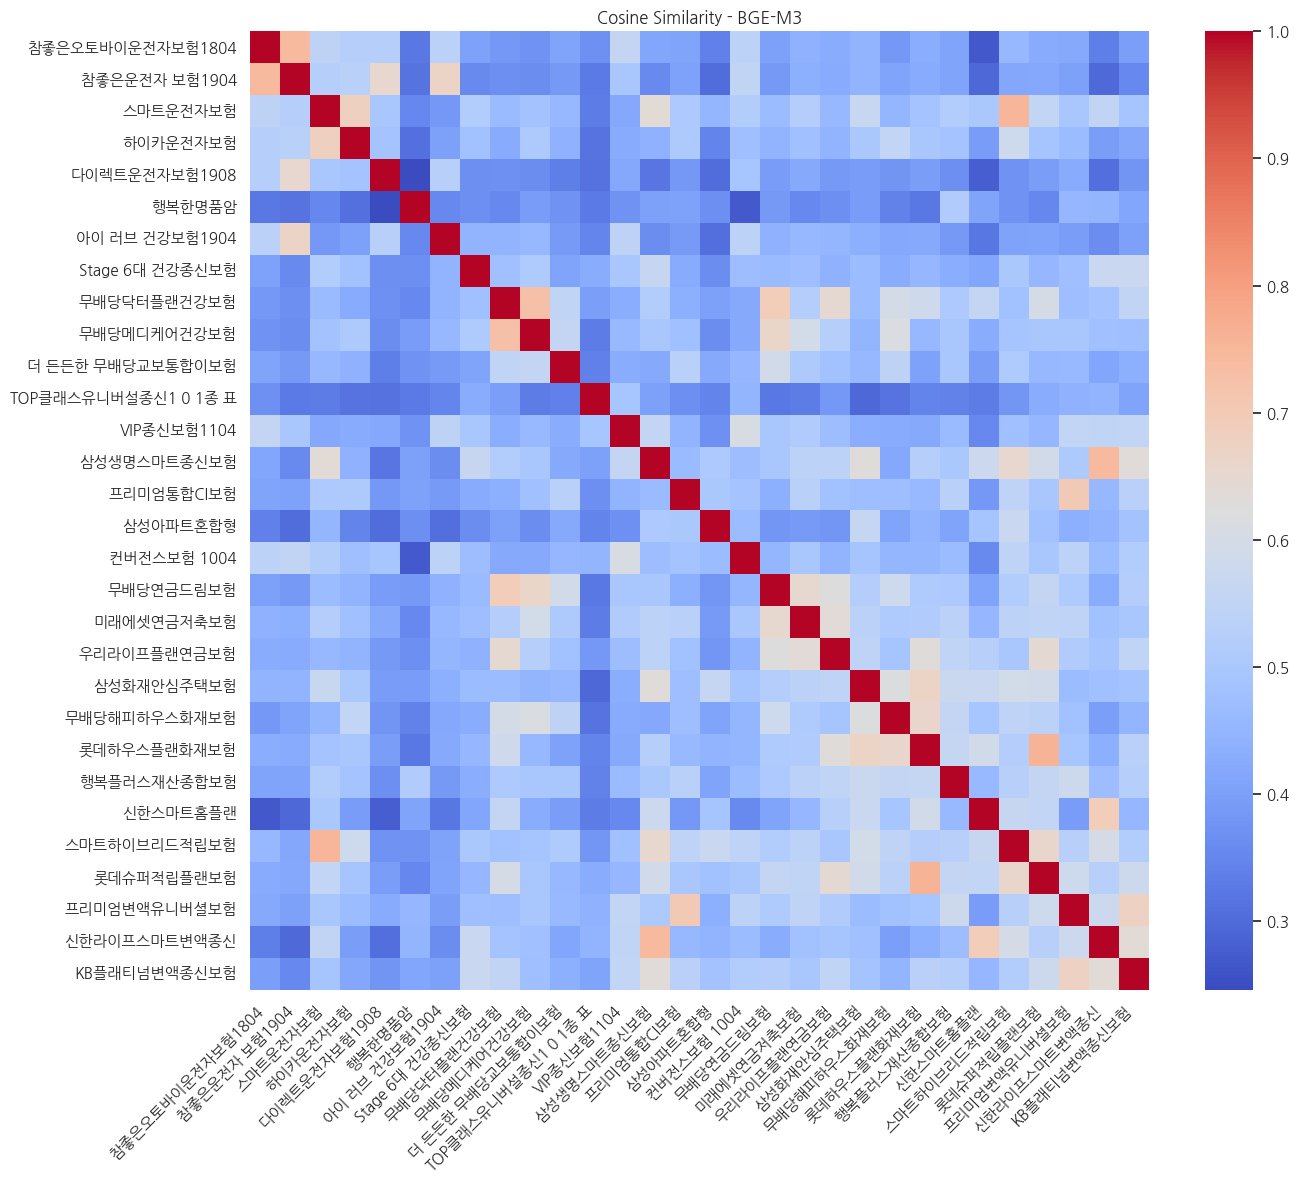


▶ 유사도 0.85 이상인 상품명 쌍 (BGE-M3):
  - 없음

▶ Processing model: KURE-v1


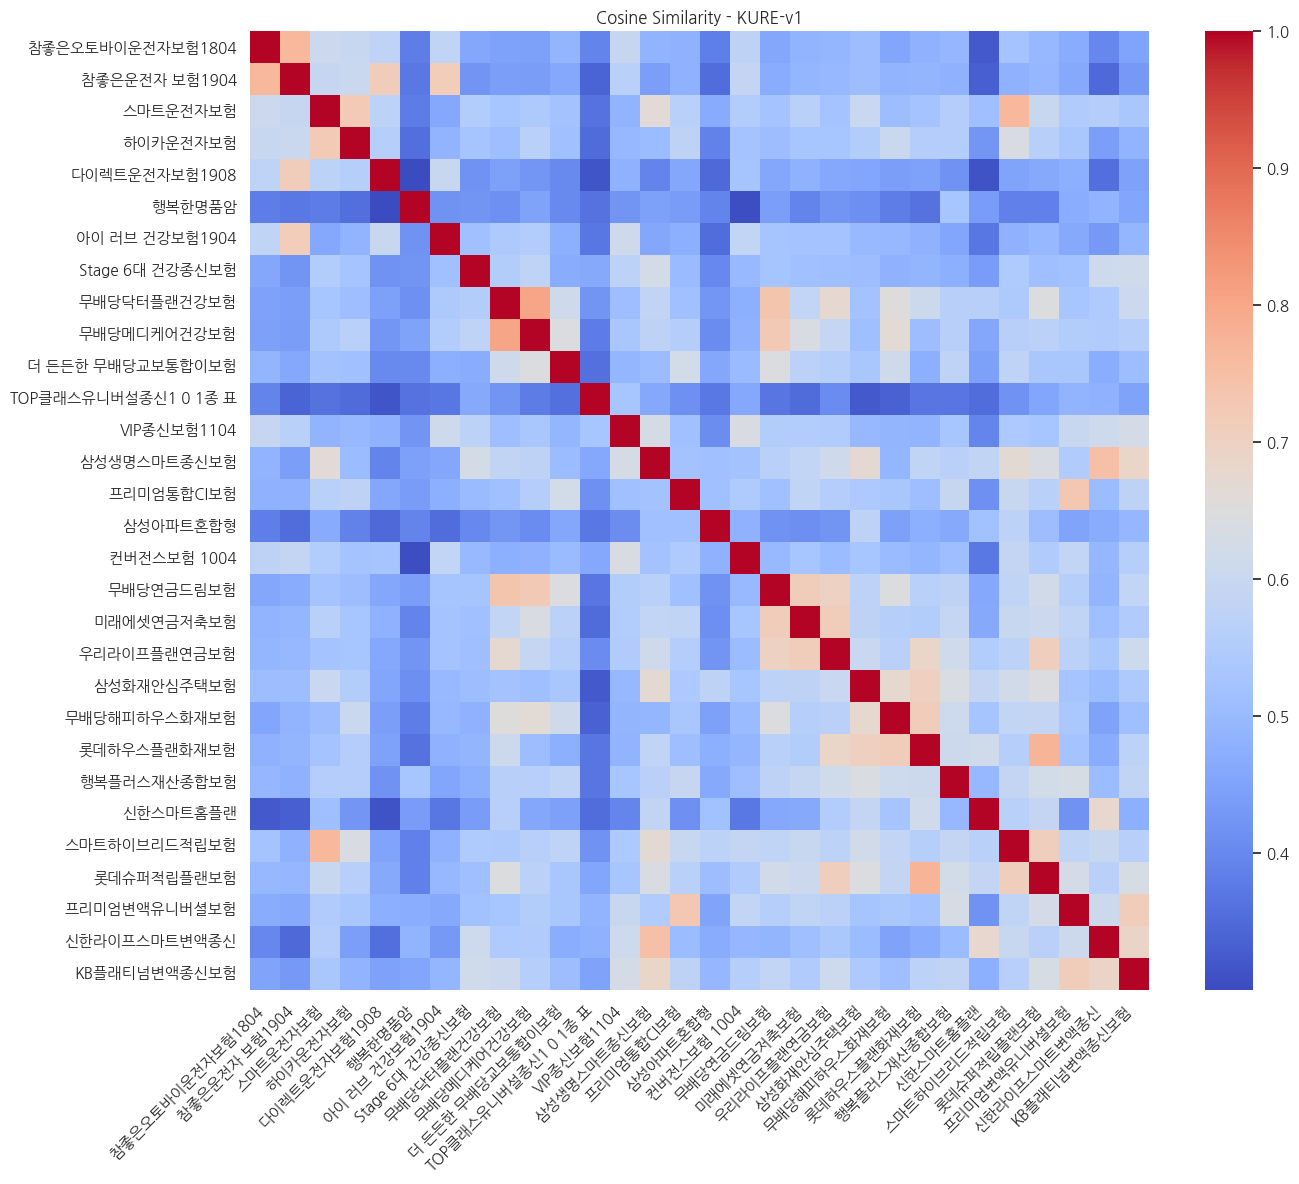


▶ 유사도 0.85 이상인 상품명 쌍 (KURE-v1):
  - 없음

▶ Processing model: Nomic-Embed-V2


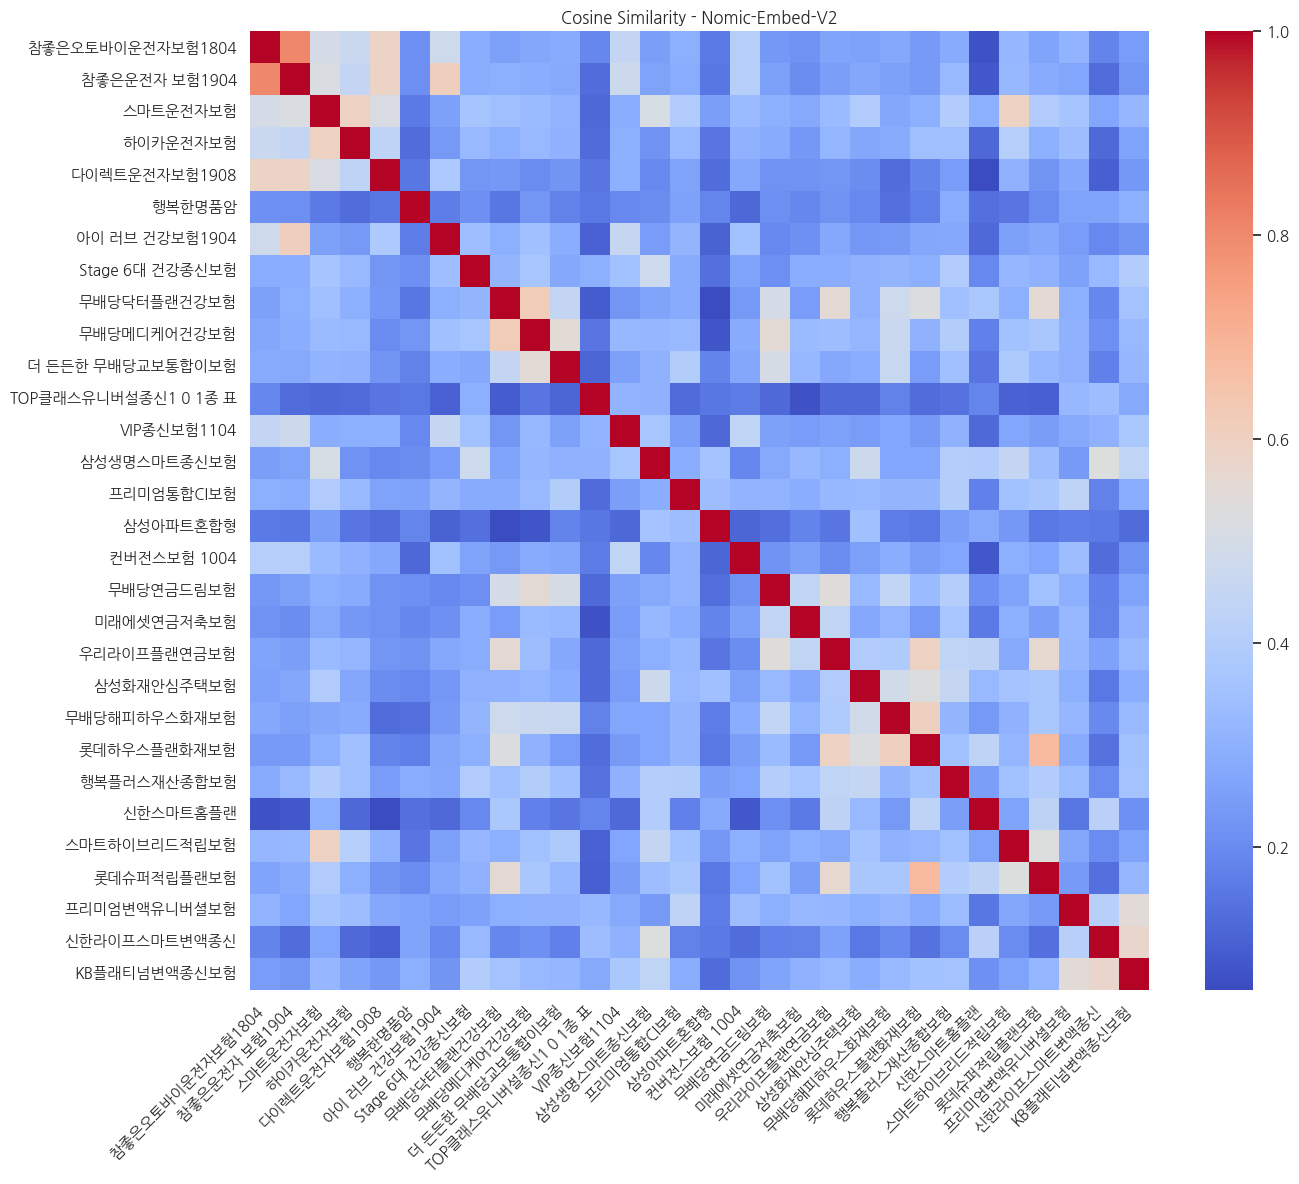


▶ 유사도 0.85 이상인 상품명 쌍 (Nomic-Embed-V2):
  - 없음

▶ Processing model: Qwen3-Embedding
⚠️ Error loading Qwen3-Embedding: Qwen/Qwen3-embedding is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

▶ Processing model: E5


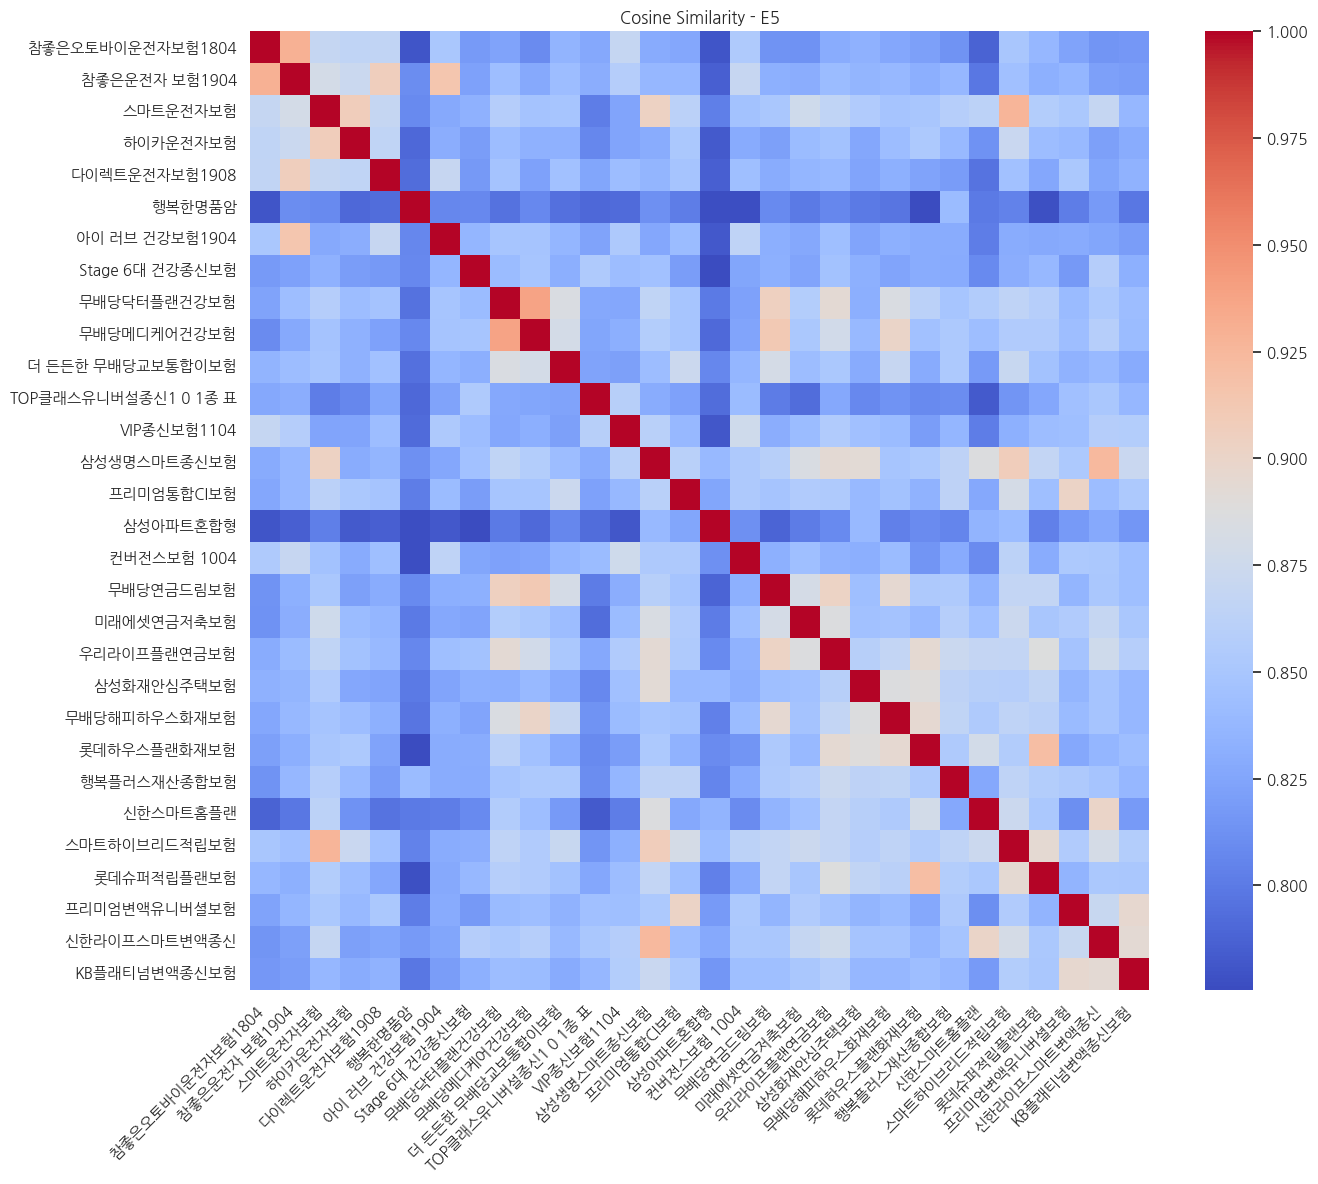


▶ 유사도 0.85 이상인 상품명 쌍 (E5):
  - (무배당닥터플랜건강보험) <-> (무배당메디케어건강보험) | Cosine Similarity: 0.9379
  - (참좋은오토바이운전자보험1804) <-> (참좋은운전자 보험1904) | Cosine Similarity: 0.9298
  - (스마트운전자보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.9267
  - (삼성생명스마트종신보험) <-> (신한라이프스마트변액종신) | Cosine Similarity: 0.9240
  - (롯데하우스플랜화재보험) <-> (롯데슈퍼적립플랜보험) | Cosine Similarity: 0.9205
  - (참좋은운전자 보험1904) <-> (아이 러브 건강보험1904) | Cosine Similarity: 0.9146
  - (무배당메디케어건강보험) <-> (무배당연금드림보험) | Cosine Similarity: 0.9123
  - (삼성생명스마트종신보험) <-> (스마트하이브리드적립보험) | Cosine Similarity: 0.9077
  - (스마트운전자보험) <-> (하이카운전자보험) | Cosine Similarity: 0.9076
  - (참좋은운전자 보험1904) <-> (다이렉트운전자보험1908) | Cosine Similarity: 0.9066
  - (무배당닥터플랜건강보험) <-> (무배당연금드림보험) | Cosine Similarity: 0.9048
  - (스마트운전자보험) <-> (삼성생명스마트종신보험) | Cosine Similarity: 0.9033
  - (무배당연금드림보험) <-> (우리라이프플랜연금보험) | Cosine Similarity: 0.9025
  - (프리미엄통합CI보험) <-> (프리미엄변액유니버셜보험) | Cosine Similarity: 0.9014
  - (무배당메디케어건강보험) <-> (무배당해피하우스화재보험) | Cosine Similarity: 0.9003
  - (신한스마트홈

,Model,Coverage@0.85,AvgSim@Top10,MeanPairwiseSim
0,BGE-M3,0.00%,0.7169,0.4672
1,KURE-v1,0.00%,0.7491,0.5189
2,Nomic-Embed-V2,0.00%,0.6275,0.2894
3,E5,34.71%,0.9188,0.8409


In [11]:
import pandas as pd

# ✅ 메트릭 계산 함수들
def compute_coverage_above_threshold(similarity_matrix, threshold):
    num_items = similarity_matrix.shape[0]
    total_pairs = num_items * (num_items - 1) / 2
    count = 0
    for i in range(num_items):
        for j in range(i+1, num_items):
            if similarity_matrix[i, j] >= threshold:
                count += 1
    return (count / total_pairs) * 100  # %

def compute_avg_sim_top_k(similarity_matrix, k):
    sims = []
    num_items = similarity_matrix.shape[0]
    for i in range(num_items):
        for j in range(i+1, num_items):
            sims.append(similarity_matrix[i, j])
    sims = sorted(sims, reverse=True)
    top_k_sims = sims[:k]
    return np.mean(top_k_sims)

def compute_mean_pairwise_sim(similarity_matrix):
    sims = []
    num_items = similarity_matrix.shape[0]
    for i in range(num_items):
        for j in range(i+1, num_items):
            sims.append(similarity_matrix[i, j])
    return np.mean(sims)

# ✅ 결과 저장용 리스트 초기화
results = []

# Threshold / Top-K 설정
similarity_threshold = 0.85
top_k = 10

# ✅ 실행 (기존 루프 그대로 사용)
for display_name, model_id in model_names.items():
    try:
        print(f"\n▶ Processing model: {display_name}")
        embeddings = get_embeddings(model_id, product_names)
        similarity_matrix = cosine_similarity(embeddings)

        # Heatmap
        plot_similarity_matrix(similarity_matrix, product_names, display_name)

        # Threshold 쌍 출력
        threshold_pairs = get_similar_pairs_above_threshold(similarity_matrix, product_names, threshold=similarity_threshold)
        print(f"\n▶ 유사도 {similarity_threshold} 이상인 상품명 쌍 ({display_name}):")
        if len(threshold_pairs) == 0:
            print("  - 없음")
        else:
            for p1, p2, score in threshold_pairs:
                print(f"  - ({p1}) <-> ({p2}) | Cosine Similarity: {score:.4f}")

        # 메트릭 계산
        coverage = compute_coverage_above_threshold(similarity_matrix, similarity_threshold)
        avg_sim_top_k = compute_avg_sim_top_k(similarity_matrix, top_k)
        mean_pairwise_sim = compute_mean_pairwise_sim(similarity_matrix)

        # 결과 저장
        results.append({
            "Model": display_name,
            f"Coverage@{similarity_threshold}": f"{coverage:.2f}%",
            f"AvgSim@Top{top_k}": f"{avg_sim_top_k:.4f}",
            "MeanPairwiseSim": f"{mean_pairwise_sim:.4f}"
        })

    except Exception as e:
        print(f"⚠️ Error loading {display_name}: {e}")

# ✅ 최종 비교표 출력
results_df = pd.DataFrame(results)
print("\n✅ 모델 비교 결과:")
display(results_df)



▶ [Clustering 단계] Processing model: BGE-M3


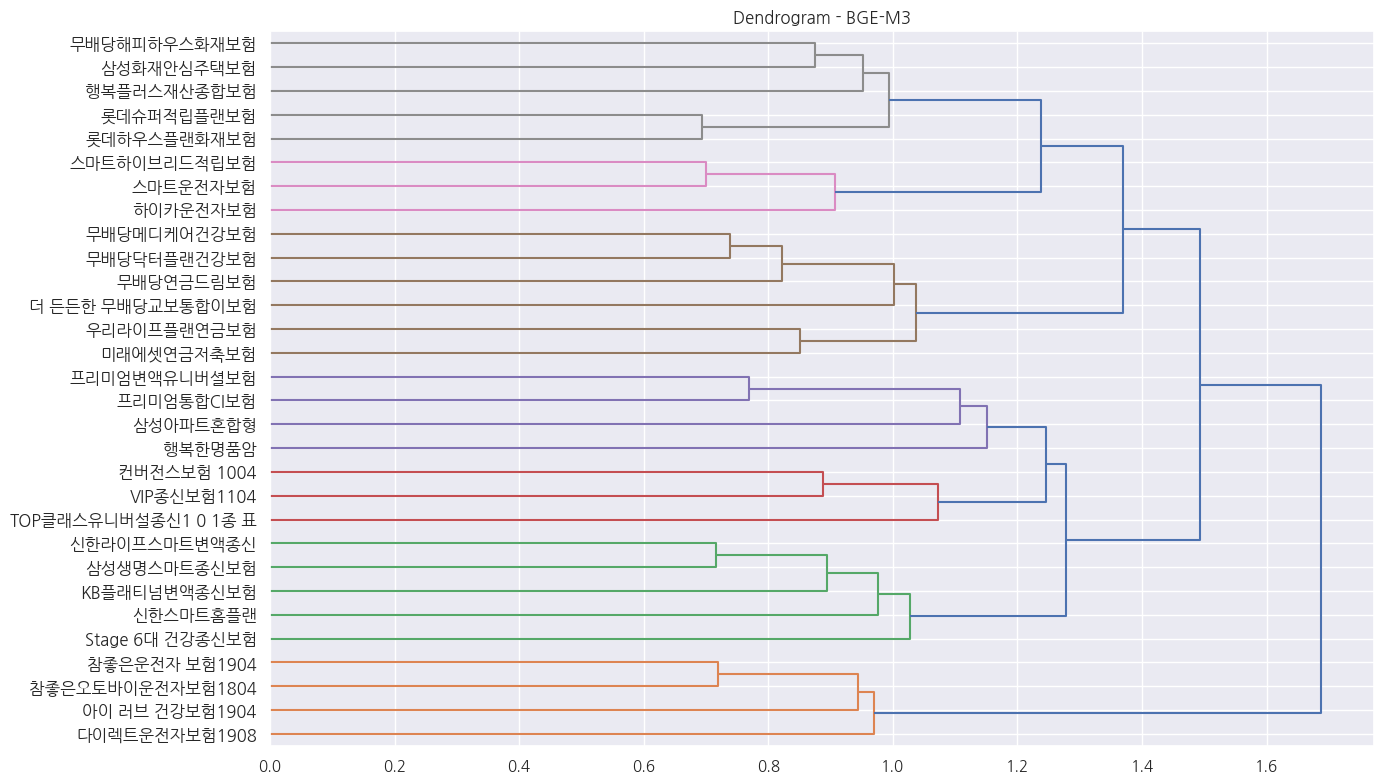


▶ BGE-M3 Clustering 결과:
  - Cluster 0: ['행복한명품암', 'TOP클래스유니버설종신1 0 1종 표', 'VIP종신보험1104', '프리미엄통합CI보험', '삼성아파트혼합형', '컨버전스보험 1004', '프리미엄변액유니버셜보험']
  - Cluster 1: ['무배당닥터플랜건강보험', '무배당메디케어건강보험', '더 든든한 무배당교보통합이보험', '무배당연금드림보험', '미래에셋연금저축보험', '우리라이프플랜연금보험']
  - Cluster 2: ['스마트운전자보험', '하이카운전자보험', '삼성화재안심주택보험', '무배당해피하우스화재보험', '롯데하우스플랜화재보험', '행복플러스재산종합보험', '스마트하이브리드적립보험', '롯데슈퍼적립플랜보험']
  - Cluster 3: ['참좋은오토바이운전자보험1804', '참좋은운전자 보험1904', '다이렉트운전자보험1908', '아이 러브 건강보험1904']
  - Cluster 4: ['Stage 6대 건강종신보험', '삼성생명스마트종신보험', '신한스마트홈플랜', '신한라이프스마트변액종신', 'KB플래티넘변액종신보험']

▶ [Clustering 단계] Processing model: KURE-v1


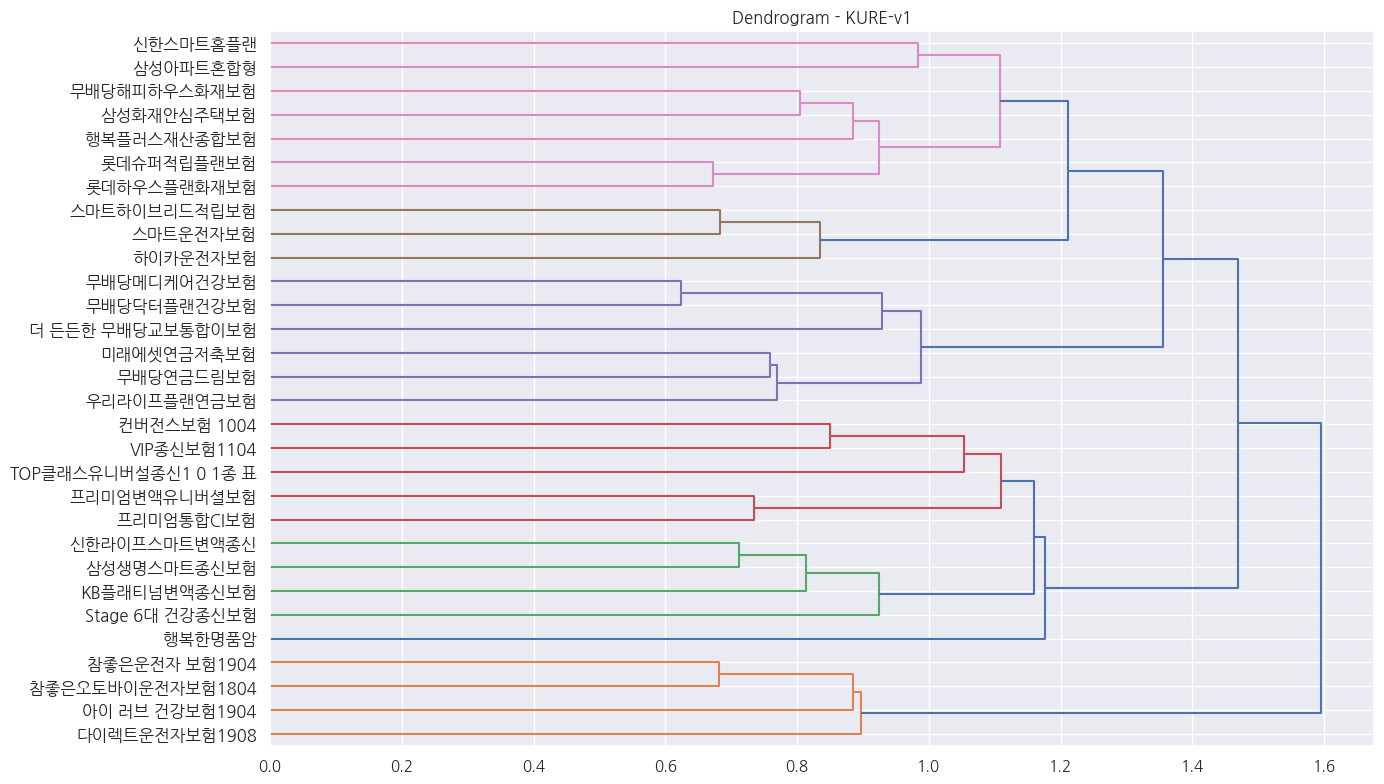


▶ KURE-v1 Clustering 결과:
  - Cluster 0: ['행복한명품암', 'Stage 6대 건강종신보험', 'TOP클래스유니버설종신1 0 1종 표', 'VIP종신보험1104', '삼성생명스마트종신보험', '프리미엄통합CI보험', '컨버전스보험 1004', '프리미엄변액유니버셜보험', '신한라이프스마트변액종신', 'KB플래티넘변액종신보험']
  - Cluster 1: ['무배당닥터플랜건강보험', '무배당메디케어건강보험', '더 든든한 무배당교보통합이보험', '무배당연금드림보험', '미래에셋연금저축보험', '우리라이프플랜연금보험']
  - Cluster 2: ['삼성아파트혼합형', '삼성화재안심주택보험', '무배당해피하우스화재보험', '롯데하우스플랜화재보험', '행복플러스재산종합보험', '신한스마트홈플랜', '롯데슈퍼적립플랜보험']
  - Cluster 3: ['참좋은오토바이운전자보험1804', '참좋은운전자 보험1904', '다이렉트운전자보험1908', '아이 러브 건강보험1904']
  - Cluster 4: ['스마트운전자보험', '하이카운전자보험', '스마트하이브리드적립보험']

▶ [Clustering 단계] Processing model: Nomic-Embed-V2


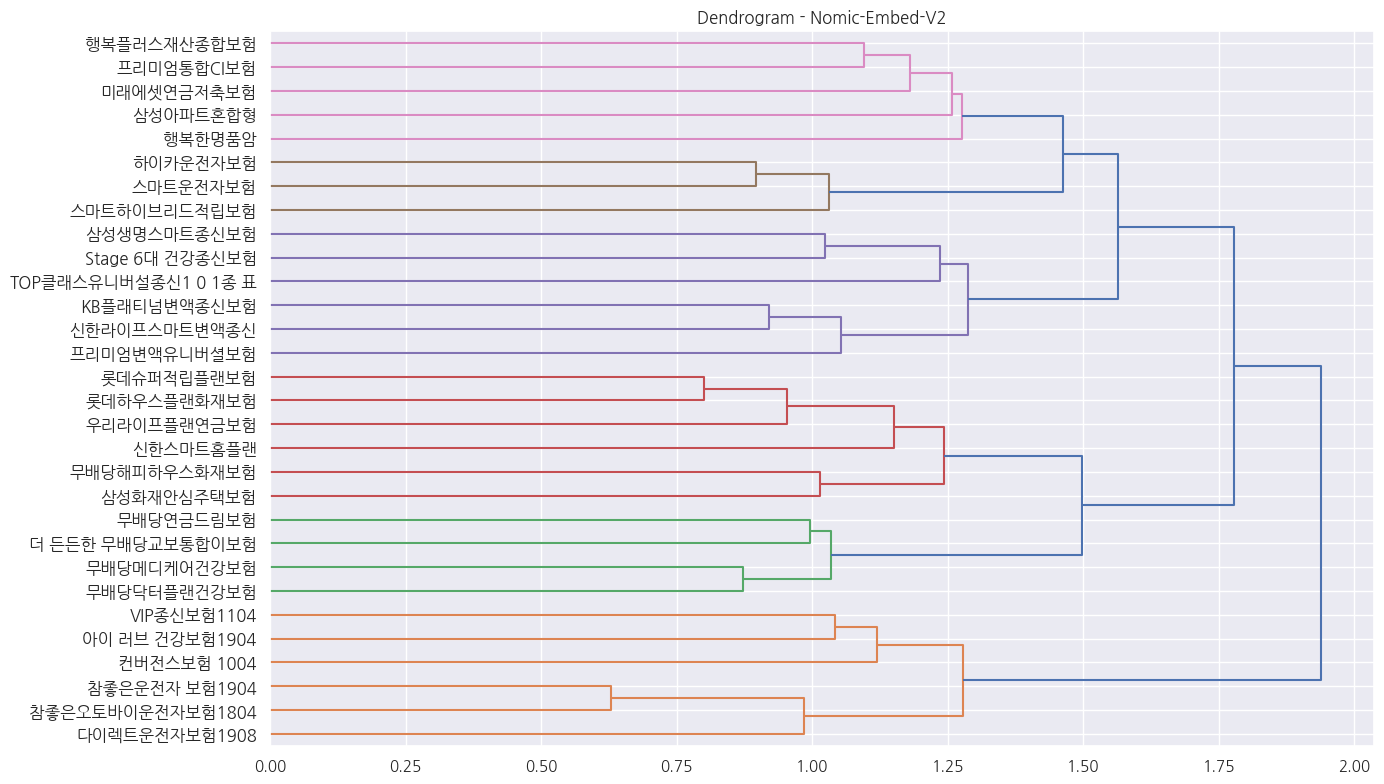


▶ Nomic-Embed-V2 Clustering 결과:
  - Cluster 0: ['스마트운전자보험', '하이카운전자보험', '행복한명품암', '프리미엄통합CI보험', '삼성아파트혼합형', '미래에셋연금저축보험', '행복플러스재산종합보험', '스마트하이브리드적립보험']
  - Cluster 1: ['Stage 6대 건강종신보험', 'TOP클래스유니버설종신1 0 1종 표', '삼성생명스마트종신보험', '프리미엄변액유니버셜보험', '신한라이프스마트변액종신', 'KB플래티넘변액종신보험']
  - Cluster 2: ['우리라이프플랜연금보험', '삼성화재안심주택보험', '무배당해피하우스화재보험', '롯데하우스플랜화재보험', '신한스마트홈플랜', '롯데슈퍼적립플랜보험']
  - Cluster 3: ['참좋은오토바이운전자보험1804', '참좋은운전자 보험1904', '다이렉트운전자보험1908', '아이 러브 건강보험1904', 'VIP종신보험1104', '컨버전스보험 1004']
  - Cluster 4: ['무배당닥터플랜건강보험', '무배당메디케어건강보험', '더 든든한 무배당교보통합이보험', '무배당연금드림보험']

▶ [Clustering 단계] Processing model: Qwen3-Embedding
⚠️ Clustering Error loading Qwen3-Embedding: Qwen/Qwen3-embedding is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

▶ [Clustering 단계] Processing m

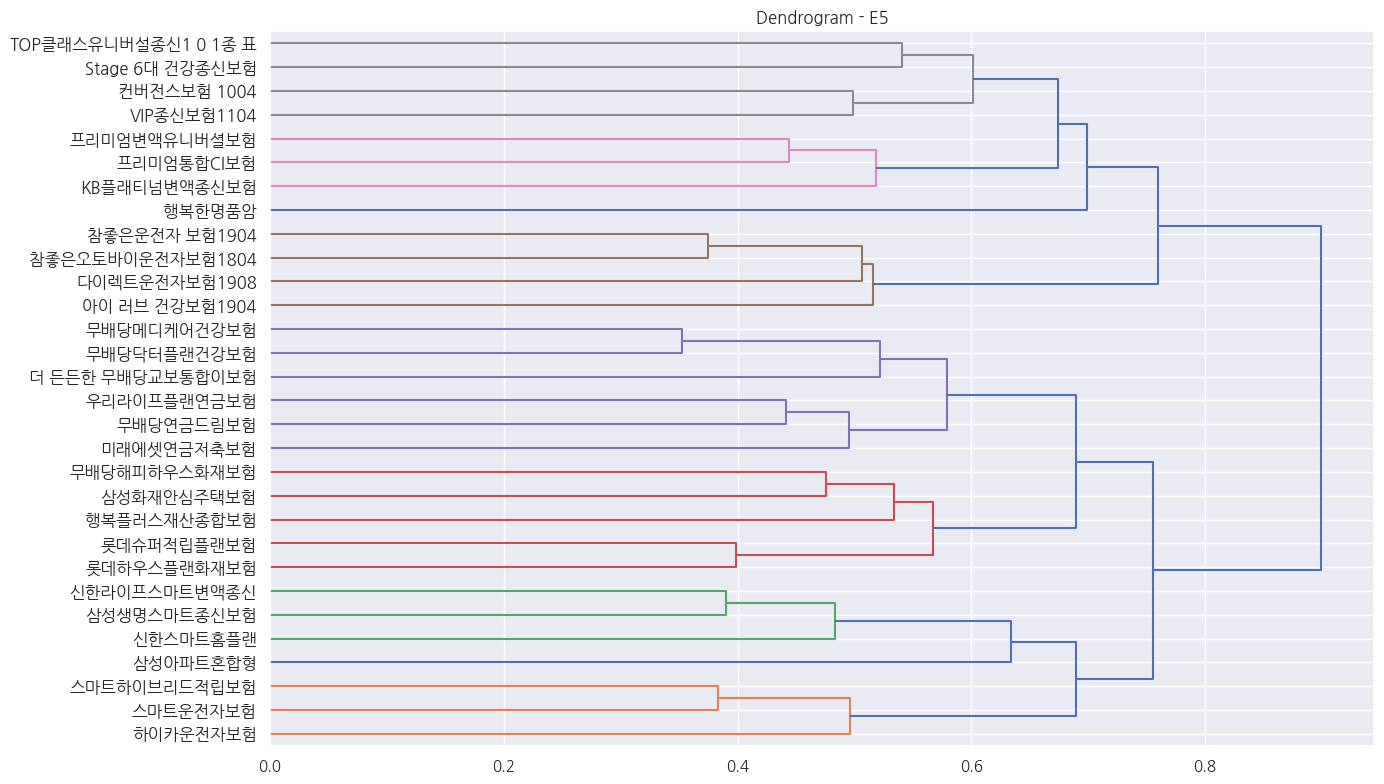


▶ E5 Clustering 결과:
  - Cluster 0: ['무배당닥터플랜건강보험', '무배당메디케어건강보험', '더 든든한 무배당교보통합이보험', '무배당연금드림보험', '미래에셋연금저축보험', '우리라이프플랜연금보험', '삼성화재안심주택보험', '무배당해피하우스화재보험', '롯데하우스플랜화재보험', '행복플러스재산종합보험', '롯데슈퍼적립플랜보험']
  - Cluster 1: ['스마트운전자보험', '하이카운전자보험', '삼성생명스마트종신보험', '삼성아파트혼합형', '신한스마트홈플랜', '스마트하이브리드적립보험', '신한라이프스마트변액종신']
  - Cluster 2: ['참좋은오토바이운전자보험1804', '참좋은운전자 보험1904', '다이렉트운전자보험1908', '아이 러브 건강보험1904']
  - Cluster 3: ['Stage 6대 건강종신보험', 'TOP클래스유니버설종신1 0 1종 표', 'VIP종신보험1104', '프리미엄통합CI보험', '컨버전스보험 1004', '프리미엄변액유니버셜보험', 'KB플래티넘변액종신보험']
  - Cluster 4: ['행복한명품암']

▶ [Clustering 단계] Processing model: KANANA
⚠️ Clustering Error loading KANANA: cannot import name 'LLAMA_INPUTS_DOCSTRING' from 'transformers.models.llama.modeling_llama' (/usr/local/lib/python3.11/dist-packages/transformers/models/llama/modeling_llama.py)


In [13]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch

# ✅ Dendrogram 그리기 함수
def plot_dendrogram(model_name, embeddings, labels):
    linked = linkage(embeddings, 'ward')
    plt.figure(figsize=(14, 8))
    dendrogram(linked, labels=labels, orientation='right', leaf_font_size=12)
    plt.title(f"Dendrogram - {model_name}")
    plt.tight_layout()
    plt.show()

# ✅ Agglomerative Clustering 결과 출력 함수
def print_cluster_assignments(model_name, cluster_labels, labels):
    cluster_dict = {}
    for label, cluster_id in zip(labels, cluster_labels):
        cluster_dict.setdefault(cluster_id, []).append(label)

    print(f"\n▶ {model_name} Clustering 결과:")
    for cluster_id, members in sorted(cluster_dict.items()):
        print(f"  - Cluster {cluster_id}: {members}")

# ✅ Clustering 실행 (n_clusters 설정 가능 → 실험적으로 조정해보세요)
n_clusters = 5  # 추천: 4~6개 정도부터 시도

for display_name, model_id in model_names.items():
    try:
        print(f"\n▶ [Clustering 단계] Processing model: {display_name}")
        embeddings = get_embeddings(model_id, product_names)

        # Agglomerative Clustering 적용
        clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
        cluster_labels = clustering.fit_predict(embeddings)

        # Dendrogram 출력
        plot_dendrogram(display_name, embeddings, product_names)

        # Cluster 구성 출력
        print_cluster_assignments(display_name, cluster_labels, product_names)

    except Exception as e:
        print(f"⚠️ Clustering Error loading {display_name}: {e}")

In [14]:
import umap
from sklearn.manifold import TSNE

# ✅ UMAP 시각화 함수
def plot_umap(embeddings, cluster_labels, labels, model_name):
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
    umap_embeddings = reducer.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    num_clusters = len(set(cluster_labels))
    cmap = plt.cm.get_cmap('tab10', num_clusters)

    for cluster_id in set(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        plt.scatter(umap_embeddings[indices, 0], umap_embeddings[indices, 1],
                    label=f'Cluster {cluster_id}', s=100, alpha=0.8, color=cmap(cluster_id))

        # 상품명 label 표시 (optional)
        for i in indices:
            plt.text(umap_embeddings[i, 0]+0.2, umap_embeddings[i, 1], labels[i], fontsize=9)

    plt.title(f"UMAP - {model_name} (Clustered)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ✅ t-SNE 시각화 함수
def plot_tsne(embeddings, cluster_labels, labels, model_name):
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init='pca', learning_rate='auto')
    tsne_embeddings = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    num_clusters = len(set(cluster_labels))
    cmap = plt.cm.get_cmap('tab10', num_clusters)

    for cluster_id in set(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        plt.scatter(tsne_embeddings[indices, 0], tsne_embeddings[indices, 1],
                    label=f'Cluster {cluster_id}', s=100, alpha=0.8, color=cmap(cluster_id))

        # 상품명 label 표시 (optional)
        for i in indices:
            plt.text(tsne_embeddings[i, 0]+0.2, tsne_embeddings[i, 1], labels[i], fontsize=9)

    plt.title(f"t-SNE - {model_name} (Clustered)")
    plt.legend()
    plt.tight_layout()
    plt.show()



▶ [Clustering 단계] Processing model: BGE-M3


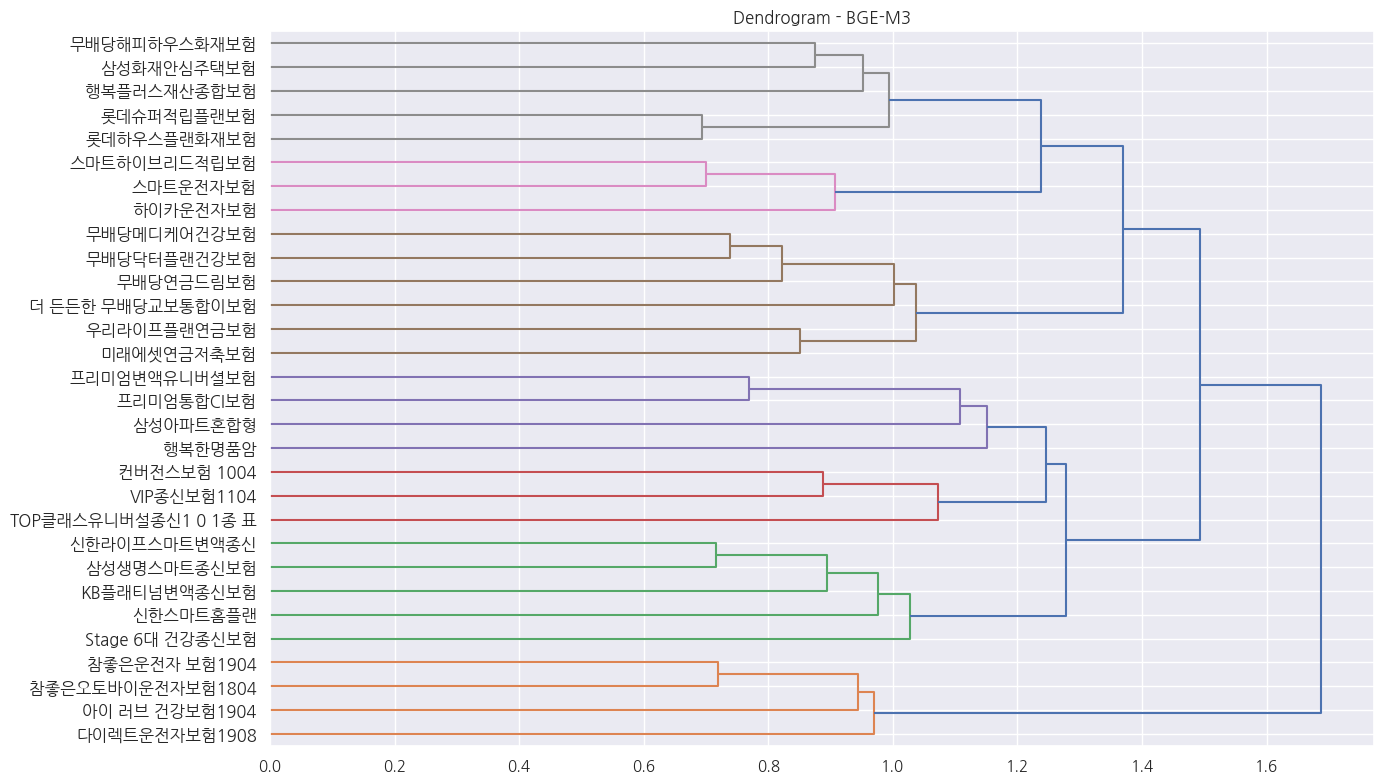


▶ BGE-M3 Clustering 결과:
  - Cluster 0: ['행복한명품암', 'TOP클래스유니버설종신1 0 1종 표', 'VIP종신보험1104', '프리미엄통합CI보험', '삼성아파트혼합형', '컨버전스보험 1004', '프리미엄변액유니버셜보험']
  - Cluster 1: ['무배당닥터플랜건강보험', '무배당메디케어건강보험', '더 든든한 무배당교보통합이보험', '무배당연금드림보험', '미래에셋연금저축보험', '우리라이프플랜연금보험']
  - Cluster 2: ['스마트운전자보험', '하이카운전자보험', '삼성화재안심주택보험', '무배당해피하우스화재보험', '롯데하우스플랜화재보험', '행복플러스재산종합보험', '스마트하이브리드적립보험', '롯데슈퍼적립플랜보험']
  - Cluster 3: ['참좋은오토바이운전자보험1804', '참좋은운전자 보험1904', '다이렉트운전자보험1908', '아이 러브 건강보험1904']
  - Cluster 4: ['Stage 6대 건강종신보험', '삼성생명스마트종신보험', '신한스마트홈플랜', '신한라이프스마트변액종신', 'KB플래티넘변액종신보험']


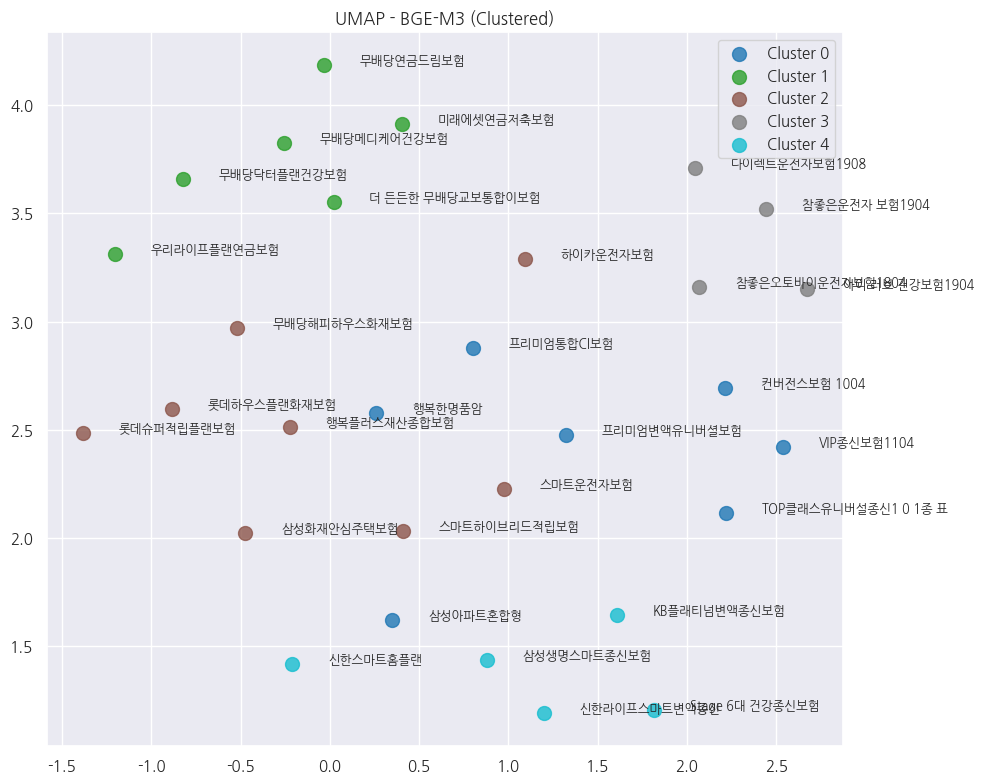

⚠️ Clustering Error loading BGE-M3: perplexity must be less than n_samples

▶ [Clustering 단계] Processing model: KURE-v1


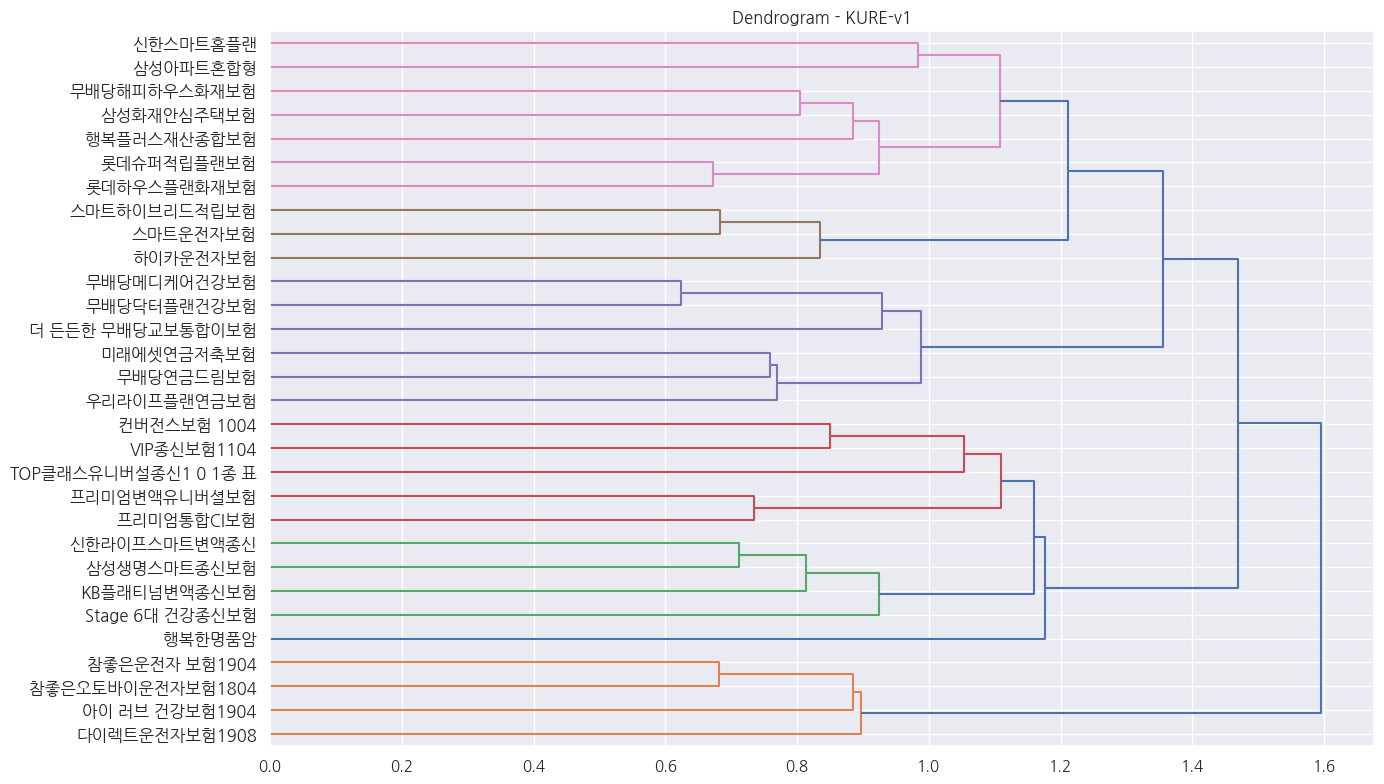


▶ KURE-v1 Clustering 결과:
  - Cluster 0: ['행복한명품암', 'Stage 6대 건강종신보험', 'TOP클래스유니버설종신1 0 1종 표', 'VIP종신보험1104', '삼성생명스마트종신보험', '프리미엄통합CI보험', '컨버전스보험 1004', '프리미엄변액유니버셜보험', '신한라이프스마트변액종신', 'KB플래티넘변액종신보험']
  - Cluster 1: ['무배당닥터플랜건강보험', '무배당메디케어건강보험', '더 든든한 무배당교보통합이보험', '무배당연금드림보험', '미래에셋연금저축보험', '우리라이프플랜연금보험']
  - Cluster 2: ['삼성아파트혼합형', '삼성화재안심주택보험', '무배당해피하우스화재보험', '롯데하우스플랜화재보험', '행복플러스재산종합보험', '신한스마트홈플랜', '롯데슈퍼적립플랜보험']
  - Cluster 3: ['참좋은오토바이운전자보험1804', '참좋은운전자 보험1904', '다이렉트운전자보험1908', '아이 러브 건강보험1904']
  - Cluster 4: ['스마트운전자보험', '하이카운전자보험', '스마트하이브리드적립보험']


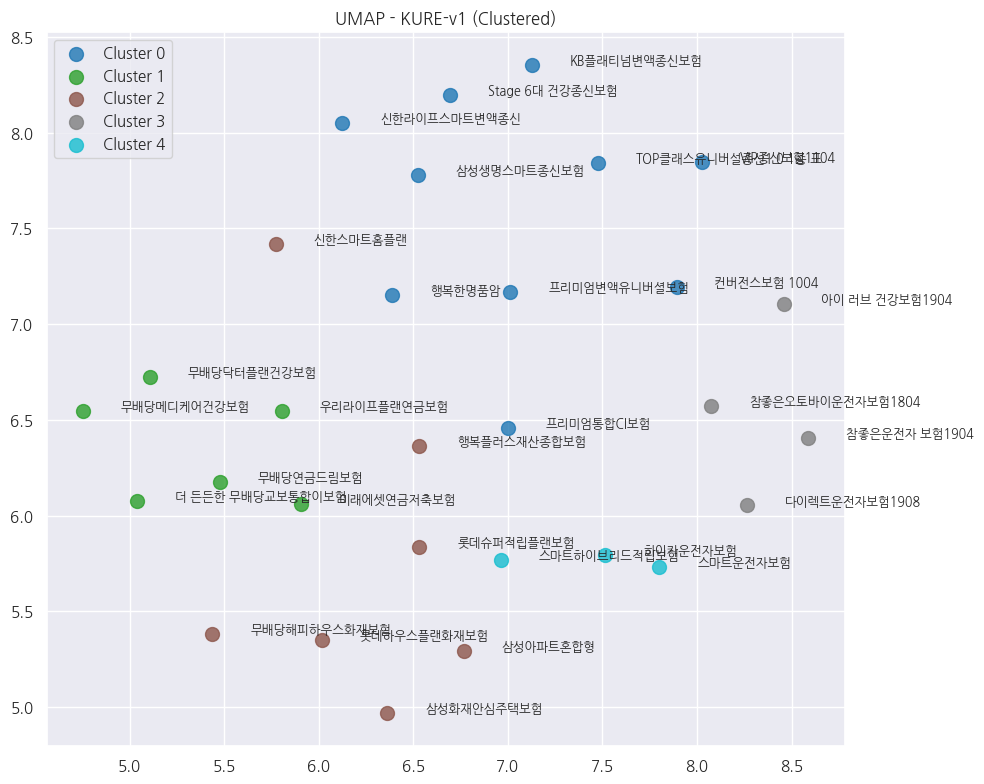

⚠️ Clustering Error loading KURE-v1: perplexity must be less than n_samples

▶ [Clustering 단계] Processing model: Nomic-Embed-V2


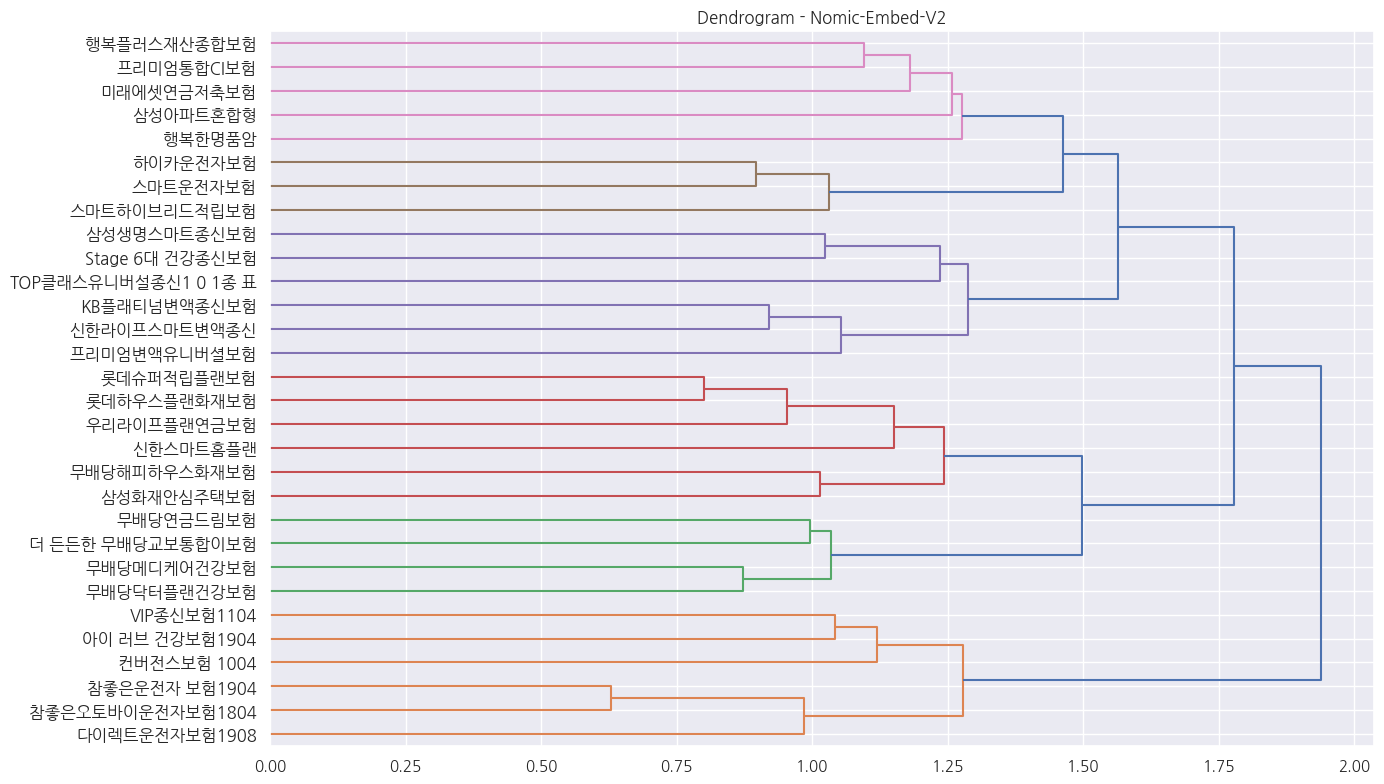


▶ Nomic-Embed-V2 Clustering 결과:
  - Cluster 0: ['스마트운전자보험', '하이카운전자보험', '행복한명품암', '프리미엄통합CI보험', '삼성아파트혼합형', '미래에셋연금저축보험', '행복플러스재산종합보험', '스마트하이브리드적립보험']
  - Cluster 1: ['Stage 6대 건강종신보험', 'TOP클래스유니버설종신1 0 1종 표', '삼성생명스마트종신보험', '프리미엄변액유니버셜보험', '신한라이프스마트변액종신', 'KB플래티넘변액종신보험']
  - Cluster 2: ['우리라이프플랜연금보험', '삼성화재안심주택보험', '무배당해피하우스화재보험', '롯데하우스플랜화재보험', '신한스마트홈플랜', '롯데슈퍼적립플랜보험']
  - Cluster 3: ['참좋은오토바이운전자보험1804', '참좋은운전자 보험1904', '다이렉트운전자보험1908', '아이 러브 건강보험1904', 'VIP종신보험1104', '컨버전스보험 1004']
  - Cluster 4: ['무배당닥터플랜건강보험', '무배당메디케어건강보험', '더 든든한 무배당교보통합이보험', '무배당연금드림보험']


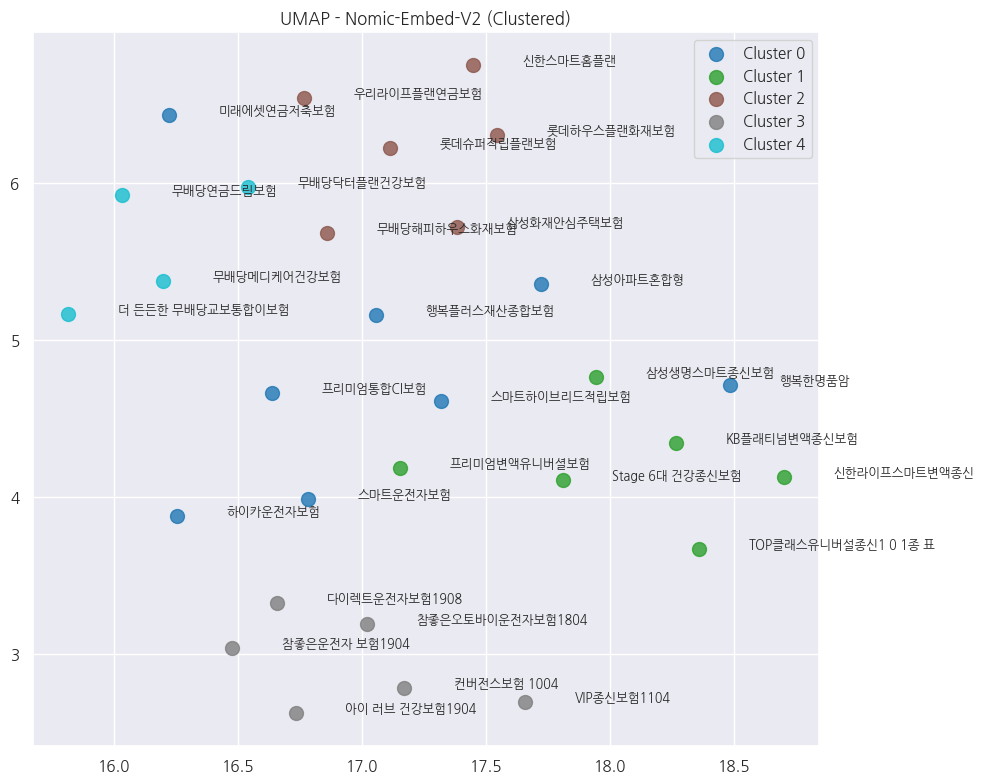

⚠️ Clustering Error loading Nomic-Embed-V2: perplexity must be less than n_samples

▶ [Clustering 단계] Processing model: Qwen3-Embedding
⚠️ Clustering Error loading Qwen3-Embedding: Qwen/Qwen3-embedding is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

▶ [Clustering 단계] Processing model: E5


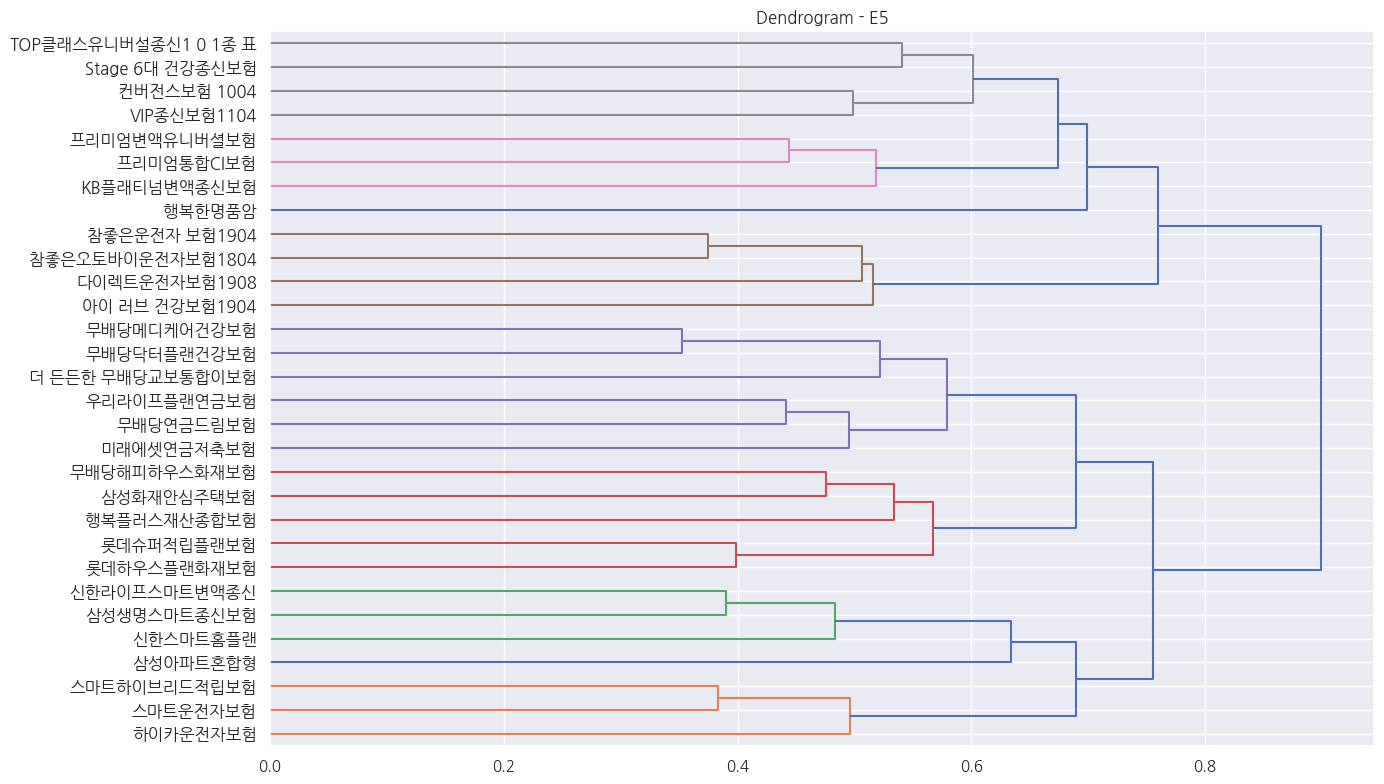


▶ E5 Clustering 결과:
  - Cluster 0: ['무배당닥터플랜건강보험', '무배당메디케어건강보험', '더 든든한 무배당교보통합이보험', '무배당연금드림보험', '미래에셋연금저축보험', '우리라이프플랜연금보험', '삼성화재안심주택보험', '무배당해피하우스화재보험', '롯데하우스플랜화재보험', '행복플러스재산종합보험', '롯데슈퍼적립플랜보험']
  - Cluster 1: ['스마트운전자보험', '하이카운전자보험', '삼성생명스마트종신보험', '삼성아파트혼합형', '신한스마트홈플랜', '스마트하이브리드적립보험', '신한라이프스마트변액종신']
  - Cluster 2: ['참좋은오토바이운전자보험1804', '참좋은운전자 보험1904', '다이렉트운전자보험1908', '아이 러브 건강보험1904']
  - Cluster 3: ['Stage 6대 건강종신보험', 'TOP클래스유니버설종신1 0 1종 표', 'VIP종신보험1104', '프리미엄통합CI보험', '컨버전스보험 1004', '프리미엄변액유니버셜보험', 'KB플래티넘변액종신보험']
  - Cluster 4: ['행복한명품암']


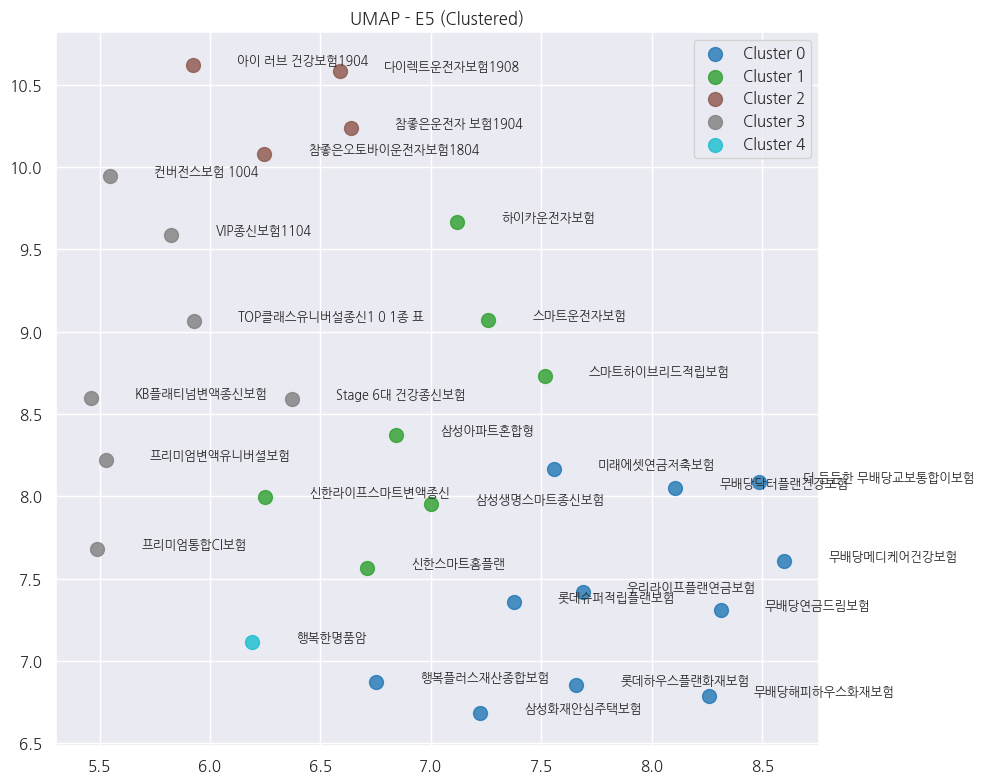

⚠️ Clustering Error loading E5: perplexity must be less than n_samples

▶ [Clustering 단계] Processing model: KANANA
⚠️ Clustering Error loading KANANA: cannot import name 'LLAMA_INPUTS_DOCSTRING' from 'transformers.models.llama.modeling_llama' (/usr/local/lib/python3.11/dist-packages/transformers/models/llama/modeling_llama.py)


In [15]:
# ✅ Clustering 실행 (n_clusters 설정 가능 → 실험적으로 조정해보세요)
n_clusters = 5  # 추천: 4~6개 정도부터 시도

for display_name, model_id in model_names.items():
    try:
        print(f"\n▶ [Clustering 단계] Processing model: {display_name}")
        embeddings = get_embeddings(model_id, product_names)

        # Agglomerative Clustering 적용
        clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
        cluster_labels = clustering.fit_predict(embeddings)

        # Dendrogram 출력
        plot_dendrogram(display_name, embeddings, product_names)

        # Cluster 구성 출력
        print_cluster_assignments(display_name, cluster_labels, product_names)

        # UMAP 시각화
        plot_umap(embeddings, cluster_labels, product_names, display_name)

        # t-SNE 시각화
        plot_tsne(embeddings, cluster_labels, product_names, display_name)

    except Exception as e:
        print(f"⚠️ Clustering Error loading {display_name}: {e}")